<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_3D_EM_Simulation_with_CuPy_K3D_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev
!pip install -q "k3d==2.18.1" trimesh "cupy-cuda12x>=13.0,<14" ipywidgets

# Enable Colab widget support.
from google.colab import output
output.enable_custom_widget_manager()

In [3]:
"""Adaptive GPU 3D electromagnetics with two microstrip patch antennas.

This Google Colab script solves the time-domain Maxwell curl equations on a
three-dimensional Cartesian grid using CuPy. Two configurable microstrip patch
antennas are represented by voxelized dielectric substrates, PEC ground planes,
PEC rectangular patches, and localized coax-like electric feed regions.

A topology-guided Metropolis-Hastings sampler identifies dynamically important
electromagnetic regions. The base solver uses a second-order staggered-difference
FDTD update everywhere. Selected interior nodes receive a blended fourth-order
staggered-derivative correction evaluated by adjacency gathers or GPU CSR sparse
operators. The sampling process allocates numerical attention only; the electric
and magnetic fields evolve deterministically from Maxwell's equations.

K3D renders a selectable electromagnetic scalar field over time together with
the resolved patch, substrate, ground, and feed geometry. The viewer, camera,
spatial decimation, animation payload, and source meshes adapt automatically to
changes in PATCH_SPECS and the simulation domain.
"""

import functools
import gc
import http.server
import math
import socketserver
import threading
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import cupy as cp
import cupyx.scipy.sparse as cpx_sparse
import k3d
import numpy as np

try:
    from google.colab import output as colab_output
except ImportError:
    colab_output = None


# =============================================================================
# Control knobs
# =============================================================================

RANDOM_SEED = 17

C0_M_S = 299_792_458.0
MU0_H_M = 4.0e-7 * math.pi
EPS0_F_M = 1.0 / (MU0_H_M * C0_M_S**2)
ETA0_OHM = math.sqrt(MU0_H_M / EPS0_F_M)

BOX_SIZE_M = (0.240, 0.180, 0.140)

# Patch-antenna parameters. Set patch_size_m=None to derive rectangular patch
# dimensions from frequency, substrate permittivity, and substrate thickness.
PATCH_SPECS = (
    {
        "center_m": (0.075, 0.090, 0.035),
        "patch_size_m": None,
        "substrate_size_m": (0.070, 0.060),
        "substrate_thickness_m": 0.006,
        "substrate_eps_r": 2.20,
        "frequency_hz": 2.45e9,
        "phase_rad": 0.0,
        "amplitude_v_m": 1.0,
        "normal_axis": "z",
        "feed_offset_m": None,
        "feed_size_m": 0.004,
    },
    {
        "center_m": (0.165, 0.090, 0.035),
        "patch_size_m": None,
        "substrate_size_m": (0.070, 0.060),
        "substrate_thickness_m": 0.006,
        "substrate_eps_r": 2.20,
        "frequency_hz": 2.45e9,
        "phase_rad": 0.55 * math.pi,
        "amplitude_v_m": 1.0,
        "normal_axis": "z",
        "feed_offset_m": None,
        "feed_size_m": 0.004,
    },
)

SOURCE_RAMP_CYCLES = 2.0
SOURCE_COUPLING = 0.50

BOUNDARY_MODE = "absorbing"  # "absorbing" or "pec"
SPONGE_CELLS = 14
SPONGE_STRENGTH = 0.075
SPONGE_POWER = 2.6

SOLVER_POLICY = "auto"  # "auto", "fdtd2", "fdtd4", or "hybrid"
AUTO_MANAGE = True

GRID_SPACING_M = None
SIM_DURATION_S = None
CFL_SAFETY = 0.88

AUTO_POINTS_PER_WAVELENGTH_MIN = 11.0
AUTO_POINTS_PER_WAVELENGTH_MAX = 14.0
AUTO_CELLS_PER_SUBSTRATE_THICKNESS = 3.0
AUTO_CELLS_ACROSS_FEED = 2.0
AUTO_CELLS_ACROSS_PATCH_MIN = 18.0
AUTO_MAX_GRID_VOXELS = 2_000_000
AUTO_GPU_MEMORY_FRACTION = 0.34
AUTO_ESTIMATED_BYTES_PER_VOXEL = 128.0
AUTO_DOMAIN_TRAVERSALS = 2.0
AUTO_MIN_SOURCE_CYCLES = 12.0
AUTO_ADAPT_PERIOD_FRACTION = 0.12

ADAPTIVE_HIGH_ORDER = True
DENSE_FOURTH_ORDER_MAX_VOXELS = 260_000
ACTIVE_FRACTION = None
ACTIVE_FRACTION_MIN = 0.050
ACTIVE_FRACTION_MAX = 0.155
ADAPT_INTERVAL_STEPS = None
MH_WALKERS = None
MH_SWEEPS = None
MH_TARGET_FLOOR = 2.0e-4
MH_BETA = 2.0
MH_VISIT_WEIGHT = 0.24
REFINEMENT_MIN_BLEND = 0.30

SPARSE_POLICY = "auto"  # "auto", "on", or "off"
SPARSE_MIN_GRID_VOXELS = 450_000
SPARSE_MIN_ACTIVE_CELLS = 18_000
SPARSE_MAX_ACTIVE_FRACTION = 0.20
SPARSE_MAX_NNZ = 3_500_000

VIS_FIELD = "e_magnitude"
# Options: ex, ey, ez, hx, hy, hz, e_magnitude, h_magnitude, em_amplitude,
# energy_density, or poynting_magnitude.
TARGET_VIS_FRAMES = 64
MAX_VIS_FRAMES = 72
MAX_VIS_VOXELS_PER_FRAME = 180_000
MAX_VIS_TOTAL_RAW_MIB = 48.0
VIS_GAIN = 1.65
VIS_SCALE_PERCENTILE = 99.4
VIS_SCALE_FLOOR_FRACTION = 0.08
VIS_DROP_LEADING_QUIET_FRAMES = True
VIS_QUIET_FRAME_FRACTION = 0.010
VIS_MIN_GLOBAL_PEAK = 1.0e-12
VIS_ALPHA_COEF = 11
VIS_VOLUME_SAMPLES = 256.0
VIS_RAY_SAMPLES = 24
VIS_FPS = 18.0
VIS_COMPRESSION_LEVEL = 2
AUTO_PLAY = True

K3D_DISPLAY_MODE = "auto"  # "auto", "widget", or "standalone"
K3D_WIDGET_MAX_RAW_MIB = 24.0
K3D_IFRAME_HEIGHT = 760
K3D_SNAPSHOT_COMPRESSION_LEVEL = 6
K3D_HIDE_GRID_LABELS = True
K3D_CAMERA_UP_AXIS = "z"
K3D_AUTO_CAMERA = True
K3D_CAMERA_DISTANCE_FACTOR = 1.55
K3D_CAMERA_SOURCE_BIAS = 0.22

SHOW_PATCH_GEOMETRY = True
SHOW_SUBSTRATES = True
SHOW_FEED_PORTS = True
PATCH_OPACITY = 1.0
GROUND_OPACITY = 0.75
SUBSTRATE_OPACITY = 0.10
FEED_OPACITY = 0.90

WRITE_STANDALONE_HTML = False
STANDALONE_HTML_PATH = "/content/topological_mh_em_patch_array.html"

CHECK_NUMERICAL_HEALTH = True
HEALTH_CHECK_INTERVAL_STEPS = None
HEALTH_MAX_E_V_M = 1.0e7
HEALTH_MAX_H_A_M = 1.0e5
PRINT_FRAME_DIAGNOSTICS = True
PRINT_PROGRESS = True

_K3D_HTTP_SERVERS: list[socketserver.TCPServer] = []


# =============================================================================
# Runtime data structures
# =============================================================================


@dataclass(frozen=True)
class ResolvedPatchSpec:
    """Resolved user-facing microstrip patch specification."""

    center_m: tuple[float, float, float]
    patch_size_m: tuple[float, float]
    substrate_size_m: tuple[float, float]
    substrate_thickness_m: float
    substrate_eps_r: float
    frequency_hz: float
    phase_rad: float
    amplitude_v_m: float
    normal_axis: str
    feed_offset_m: tuple[float, float]
    feed_size_m: float


@dataclass(frozen=True)
class RuntimeConfig:
    """Resolved numerical, adaptive, and visualization parameters."""

    shape: tuple[int, int, int]
    spacing_m: tuple[float, float, float]
    dt_s: float
    steps: int
    duration_s: float
    points_per_wavelength: float
    requested_points_per_wavelength: float
    adapt_interval_steps: int
    active_fraction_base: float
    mh_walkers: int
    mh_sweeps: int
    snapshot_stride: int
    visualization_stride: int
    solver_mode: str
    max_eps_r: float
    free_gpu_bytes: int
    total_gpu_bytes: int

    @property
    def voxel_count(self) -> int:
        """Return the number of Cartesian grid voxels."""
        return int(np.prod(self.shape))


@dataclass
class PatchAntenna:
    """GPU-resident feed support and resolved antenna geometry."""

    feed_indices: cp.ndarray
    feed_weights: cp.ndarray
    center_m: tuple[float, float, float]
    patch_size_m: tuple[float, float]
    substrate_size_m: tuple[float, float]
    substrate_thickness_m: float
    substrate_eps_r: float
    frequency_hz: float
    phase_rad: float
    amplitude_v_m: float
    normal_axis: str
    feed_offset_m: tuple[float, float]
    feed_size_m: float


@dataclass
class MaterialState:
    """GPU-resident material maps and PEC geometry."""

    epsilon_r: cp.ndarray
    inverse_epsilon: cp.ndarray
    pec_mask: cp.ndarray


@dataclass
class RefinementState:
    """Active fourth-order staggered-derivative correction state."""

    active_indices: cp.ndarray
    blend_weights: cp.ndarray
    backend: str
    operators: dict[str, Any]


# =============================================================================
# Geometry and patch-resolution helpers
# =============================================================================


_AXIS_INDEX = {"x": 0, "y": 1, "z": 2}


def _local_axes(normal_axis: str) -> tuple[int, int, int]:
    """Return local patch length, width, and normal Cartesian axes."""
    axis = normal_axis.lower()
    if axis == "x":
        return 1, 2, 0
    if axis == "y":
        return 0, 2, 1
    if axis == "z":
        return 0, 1, 2
    raise ValueError("normal_axis must be 'x', 'y', or 'z'.")


def _microstrip_patch_dimensions(
    frequency_hz: float,
    epsilon_r: float,
    substrate_thickness_m: float,
) -> tuple[float, float]:
    """Estimate resonant rectangular patch length and width."""
    width = (
        C0_M_S
        / (2.0 * frequency_hz)
        * math.sqrt(2.0 / (epsilon_r + 1.0))
    )
    effective_eps = (
        0.5 * (epsilon_r + 1.0)
        + 0.5
        * (epsilon_r - 1.0)
        * (1.0 + 12.0 * substrate_thickness_m / width) ** -0.5
    )
    width_ratio = width / substrate_thickness_m
    delta_length = (
        0.412
        * substrate_thickness_m
        * ((effective_eps + 0.3) * (width_ratio + 0.264))
        / ((effective_eps - 0.258) * (width_ratio + 0.8))
    )
    effective_length = (
        C0_M_S
        / (2.0 * frequency_hz * math.sqrt(effective_eps))
    )
    length = effective_length - 2.0 * delta_length
    if length <= 0.0 or width <= 0.0:
        raise ValueError("Automatic patch dimensions resolved to nonpositive values.")
    return float(length), float(width)


def _as_pair(value: Any, name: str) -> tuple[float, float]:
    """Convert a user value to a finite positive two-component pair."""
    pair = tuple(float(component) for component in value)
    if len(pair) != 2:
        raise ValueError(f"{name} must contain exactly two values.")
    if any(not math.isfinite(component) or component <= 0.0 for component in pair):
        raise ValueError(f"{name} must contain finite positive values.")
    return pair


def resolve_patch_specs() -> list[ResolvedPatchSpec]:
    """Validate and resolve all patch antenna dimensions and feed locations."""
    if not PATCH_SPECS:
        raise ValueError("PATCH_SPECS must contain at least one patch antenna.")

    required_keys = {
        "center_m",
        "substrate_thickness_m",
        "substrate_eps_r",
        "frequency_hz",
        "phase_rad",
        "amplitude_v_m",
        "normal_axis",
    }
    resolved: list[ResolvedPatchSpec] = []

    for index, raw in enumerate(PATCH_SPECS):
        missing = required_keys.difference(raw)
        if missing:
            missing_text = ", ".join(sorted(missing))
            raise ValueError(f"PATCH_SPECS[{index}] is missing: {missing_text}.")

        center = tuple(float(value) for value in raw["center_m"])
        if len(center) != 3 or any(not math.isfinite(value) for value in center):
            raise ValueError(
                f"PATCH_SPECS[{index}] center_m must contain three finite values."
            )

        thickness = float(raw["substrate_thickness_m"])
        epsilon_r = float(raw["substrate_eps_r"])
        frequency_hz = float(raw["frequency_hz"])
        phase_rad = float(raw["phase_rad"])
        amplitude_v_m = float(raw["amplitude_v_m"])
        normal_axis = str(raw["normal_axis"]).lower()

        if thickness <= 0.0 or not math.isfinite(thickness):
            raise ValueError(
                f"PATCH_SPECS[{index}] substrate_thickness_m must be positive."
            )
        if epsilon_r < 1.0 or not math.isfinite(epsilon_r):
            raise ValueError(
                f"PATCH_SPECS[{index}] substrate_eps_r must be at least 1."
            )
        if frequency_hz <= 0.0 or not math.isfinite(frequency_hz):
            raise ValueError(
                f"PATCH_SPECS[{index}] frequency_hz must be finite and positive."
            )
        if not math.isfinite(phase_rad) or not math.isfinite(amplitude_v_m):
            raise ValueError(
                f"PATCH_SPECS[{index}] phase_rad and amplitude_v_m must be finite."
            )
        if normal_axis not in _AXIS_INDEX:
            raise ValueError(
                f"PATCH_SPECS[{index}] normal_axis must be x, y, or z."
            )

        patch_size_raw = raw.get("patch_size_m")
        if patch_size_raw is None:
            patch_size = _microstrip_patch_dimensions(
                frequency_hz,
                epsilon_r,
                thickness,
            )
        else:
            patch_size = _as_pair(
                patch_size_raw,
                f"PATCH_SPECS[{index}] patch_size_m",
            )

        substrate_size_raw = raw.get("substrate_size_m")
        if substrate_size_raw is None:
            substrate_size = (
                max(1.25 * patch_size[0], patch_size[0] + 8.0 * thickness),
                max(1.25 * patch_size[1], patch_size[1] + 8.0 * thickness),
            )
        else:
            substrate_size = _as_pair(
                substrate_size_raw,
                f"PATCH_SPECS[{index}] substrate_size_m",
            )

        if (
            substrate_size[0] <= patch_size[0]
            or substrate_size[1] <= patch_size[1]
        ):
            raise ValueError(
                f"PATCH_SPECS[{index}] substrate_size_m must exceed patch_size_m."
            )

        feed_offset_raw = raw.get("feed_offset_m")
        if feed_offset_raw is None:
            feed_offset = (-0.20 * patch_size[0], 0.0)
        else:
            feed_offset = tuple(float(value) for value in feed_offset_raw)
            if len(feed_offset) != 2 or any(
                not math.isfinite(value) for value in feed_offset
            ):
                raise ValueError(
                    f"PATCH_SPECS[{index}] feed_offset_m must contain two "
                    "finite values."
                )

        feed_size_raw = raw.get("feed_size_m")
        if feed_size_raw is None:
            feed_size = max(0.06 * min(patch_size), 0.001)
        else:
            feed_size = float(feed_size_raw)
        if feed_size <= 0.0 or not math.isfinite(feed_size):
            raise ValueError(
                f"PATCH_SPECS[{index}] feed_size_m must be finite and positive."
            )

        half_patch_u = 0.5 * patch_size[0]
        half_patch_v = 0.5 * patch_size[1]
        half_feed = 0.5 * feed_size
        if abs(feed_offset[0]) + half_feed >= half_patch_u:
            raise ValueError(
                f"PATCH_SPECS[{index}] feed offset lies outside the patch length."
            )
        if abs(feed_offset[1]) + half_feed >= half_patch_v:
            raise ValueError(
                f"PATCH_SPECS[{index}] feed offset lies outside the patch width."
            )

        u_axis, v_axis, n_axis = _local_axes(normal_axis)
        box = tuple(float(value) for value in BOX_SIZE_M)
        ground_n = center[n_axis] - thickness
        if ground_n <= 0.0 or center[n_axis] >= box[n_axis]:
            raise ValueError(
                f"PATCH_SPECS[{index}] patch and ground planes must lie inside "
                "the simulation box."
            )

        for axis, extent in (
            (u_axis, substrate_size[0]),
            (v_axis, substrate_size[1]),
        ):
            lower = center[axis] - 0.5 * extent
            upper = center[axis] + 0.5 * extent
            if lower <= 0.0 or upper >= box[axis]:
                raise ValueError(
                    f"PATCH_SPECS[{index}] substrate footprint extends outside "
                    "BOX_SIZE_M."
                )

        resolved.append(
            ResolvedPatchSpec(
                center_m=center,
                patch_size_m=patch_size,
                substrate_size_m=substrate_size,
                substrate_thickness_m=thickness,
                substrate_eps_r=epsilon_r,
                frequency_hz=frequency_hz,
                phase_rad=phase_rad,
                amplitude_v_m=amplitude_v_m,
                normal_axis=normal_axis,
                feed_offset_m=feed_offset,
                feed_size_m=feed_size,
            )
        )

    return resolved


# =============================================================================
# Automatic configuration
# =============================================================================


def validate_control_knobs() -> None:
    """Check global numerical and visualization controls."""
    if len(BOX_SIZE_M) != 3 or any(
        not math.isfinite(float(length)) or float(length) <= 0.0
        for length in BOX_SIZE_M
    ):
        raise ValueError("BOX_SIZE_M must contain three finite positive values.")

    normalized_policy = SOLVER_POLICY.lower()
    aliases = {"dense2": "fdtd2", "dense4": "fdtd4"}
    normalized_policy = aliases.get(normalized_policy, normalized_policy)
    if normalized_policy not in {"auto", "fdtd2", "fdtd4", "hybrid"}:
        raise ValueError(
            "SOLVER_POLICY must be 'auto', 'fdtd2', 'fdtd4', or 'hybrid'."
        )

    if SPARSE_POLICY.lower() not in {"auto", "on", "off"}:
        raise ValueError("SPARSE_POLICY must be 'auto', 'on', or 'off'.")

    if BOUNDARY_MODE.lower() not in {"absorbing", "pec"}:
        raise ValueError("BOUNDARY_MODE must be 'absorbing' or 'pec'.")

    if not 0.0 < CFL_SAFETY <= 0.95:
        raise ValueError("CFL_SAFETY must lie in the interval (0, 0.95].")

    if GRID_SPACING_M is not None and (
        not math.isfinite(float(GRID_SPACING_M)) or GRID_SPACING_M <= 0.0
    ):
        raise ValueError("GRID_SPACING_M must be finite and positive or None.")

    if SIM_DURATION_S is not None and (
        not math.isfinite(float(SIM_DURATION_S)) or SIM_DURATION_S <= 0.0
    ):
        raise ValueError("SIM_DURATION_S must be finite and positive or None.")

    if AUTO_POINTS_PER_WAVELENGTH_MIN <= 0.0:
        raise ValueError("AUTO_POINTS_PER_WAVELENGTH_MIN must be positive.")
    if AUTO_POINTS_PER_WAVELENGTH_MAX < AUTO_POINTS_PER_WAVELENGTH_MIN:
        raise ValueError(
            "AUTO_POINTS_PER_WAVELENGTH_MAX must be at least the minimum."
        )

    if AUTO_CELLS_PER_SUBSTRATE_THICKNESS < 1.0:
        raise ValueError("AUTO_CELLS_PER_SUBSTRATE_THICKNESS must be at least 1.")
    if AUTO_CELLS_ACROSS_FEED < 1.0:
        raise ValueError("AUTO_CELLS_ACROSS_FEED must be at least 1.")
    if AUTO_CELLS_ACROSS_PATCH_MIN < 4.0:
        raise ValueError("AUTO_CELLS_ACROSS_PATCH_MIN must be at least 4.")

    if AUTO_MAX_GRID_VOXELS < 343:
        raise ValueError("AUTO_MAX_GRID_VOXELS must be at least 343.")
    if not 0.0 < AUTO_GPU_MEMORY_FRACTION <= 0.90:
        raise ValueError("AUTO_GPU_MEMORY_FRACTION must lie in (0, 0.90].")
    if AUTO_ESTIMATED_BYTES_PER_VOXEL <= 0.0:
        raise ValueError("AUTO_ESTIMATED_BYTES_PER_VOXEL must be positive.")

    if not 0.0 < ACTIVE_FRACTION_MIN <= ACTIVE_FRACTION_MAX < 1.0:
        raise ValueError(
            "ACTIVE_FRACTION_MIN and ACTIVE_FRACTION_MAX must satisfy "
            "0 < min <= max < 1."
        )
    if ACTIVE_FRACTION is not None and not 0.0 < ACTIVE_FRACTION < 1.0:
        raise ValueError("ACTIVE_FRACTION must lie in (0, 1) or be None.")
    if ADAPT_INTERVAL_STEPS is not None and ADAPT_INTERVAL_STEPS < 1:
        raise ValueError("ADAPT_INTERVAL_STEPS must be positive or None.")
    if MH_WALKERS is not None and MH_WALKERS < 1:
        raise ValueError("MH_WALKERS must be positive or None.")
    if MH_SWEEPS is not None and MH_SWEEPS < 1:
        raise ValueError("MH_SWEEPS must be positive or None.")
    if MH_TARGET_FLOOR <= 0.0 or MH_BETA <= 0.0:
        raise ValueError("MH_TARGET_FLOOR and MH_BETA must be positive.")
    if not 0.0 <= MH_VISIT_WEIGHT <= 1.0:
        raise ValueError("MH_VISIT_WEIGHT must lie in [0, 1].")
    if not 0.0 <= REFINEMENT_MIN_BLEND <= 1.0:
        raise ValueError("REFINEMENT_MIN_BLEND must lie in [0, 1].")

    if SPARSE_MIN_GRID_VOXELS < 1 or SPARSE_MIN_ACTIVE_CELLS < 1:
        raise ValueError("Sparse activation thresholds must be positive.")
    if not 0.0 < SPARSE_MAX_ACTIVE_FRACTION < 1.0:
        raise ValueError("SPARSE_MAX_ACTIVE_FRACTION must lie in (0, 1).")
    if SPARSE_MAX_NNZ < 24:
        raise ValueError("SPARSE_MAX_NNZ must be at least 24.")

    if TARGET_VIS_FRAMES < 1 or MAX_VIS_FRAMES < 1:
        raise ValueError("Visualization frame limits must be positive.")
    if MAX_VIS_VOXELS_PER_FRAME < 1:
        raise ValueError("MAX_VIS_VOXELS_PER_FRAME must be positive.")
    if MAX_VIS_TOTAL_RAW_MIB <= 0.0:
        raise ValueError("MAX_VIS_TOTAL_RAW_MIB must be positive.")
    if VIS_FPS <= 0.0 or VIS_ALPHA_COEF <= 0.0:
        raise ValueError("VIS_FPS and VIS_ALPHA_COEF must be positive.")
    if not 0.0 < VIS_SCALE_PERCENTILE <= 100.0:
        raise ValueError("VIS_SCALE_PERCENTILE must lie in (0, 100].")
    if not 0.0 < VIS_SCALE_FLOOR_FRACTION <= 1.0:
        raise ValueError("VIS_SCALE_FLOOR_FRACTION must lie in (0, 1].")
    if not 0.0 <= VIS_QUIET_FRAME_FRACTION < 1.0:
        raise ValueError("VIS_QUIET_FRAME_FRACTION must lie in [0, 1).")
    if VIS_MIN_GLOBAL_PEAK <= 0.0:
        raise ValueError("VIS_MIN_GLOBAL_PEAK must be positive.")

    valid_vis_fields = {
        "ex",
        "ey",
        "ez",
        "hx",
        "hy",
        "hz",
        "e_magnitude",
        "h_magnitude",
        "em_amplitude",
        "energy_density",
        "poynting_magnitude",
    }
    if VIS_FIELD.lower() not in valid_vis_fields:
        raise ValueError(
            "VIS_FIELD must select an electric, magnetic, energy, or Poynting field."
        )

    if K3D_DISPLAY_MODE.lower() not in {"auto", "widget", "standalone"}:
        raise ValueError(
            "K3D_DISPLAY_MODE must be 'auto', 'widget', or 'standalone'."
        )
    if K3D_WIDGET_MAX_RAW_MIB <= 0.0 or K3D_IFRAME_HEIGHT < 200:
        raise ValueError(
            "K3D_WIDGET_MAX_RAW_MIB must be positive and "
            "K3D_IFRAME_HEIGHT must be at least 200."
        )
    if K3D_CAMERA_UP_AXIS.lower() not in _AXIS_INDEX:
        raise ValueError("K3D_CAMERA_UP_AXIS must be 'x', 'y', or 'z'.")
    if K3D_CAMERA_DISTANCE_FACTOR <= 0.0:
        raise ValueError("K3D_CAMERA_DISTANCE_FACTOR must be positive.")
    if not 0.0 <= K3D_CAMERA_SOURCE_BIAS <= 1.0:
        raise ValueError("K3D_CAMERA_SOURCE_BIAS must lie in [0, 1].")

    if HEALTH_MAX_E_V_M <= 0.0 or HEALTH_MAX_H_A_M <= 0.0:
        raise ValueError("Electromagnetic health thresholds must be positive.")


def _grid_shape(
    box_size_m: tuple[float, float, float],
    nominal_spacing_m: float,
) -> tuple[int, int, int]:
    """Return a grid shape that exactly spans the requested box."""
    return tuple(
        max(9, int(math.ceil(length / nominal_spacing_m)) + 1)
        for length in box_size_m
    )


def _spacing_from_shape(
    box_size_m: tuple[float, float, float],
    shape: tuple[int, int, int],
) -> tuple[float, float, float]:
    """Return exact grid spacing for a box and node counts."""
    return tuple(
        length / float(count - 1)
        for length, count in zip(box_size_m, shape)
    )


def _resolved_points_per_wavelength(
    patches: list[ResolvedPatchSpec],
) -> float:
    """Choose the spatial sampling target from the source bandwidth."""
    frequencies = [patch.frequency_hz for patch in patches]
    f_max = max(frequencies)
    f_min = min(frequencies)
    bandwidth_ratio = (f_max - f_min) / max(f_max, 1.0)
    target = AUTO_POINTS_PER_WAVELENGTH_MIN + 1.75 * bandwidth_ratio
    return float(
        np.clip(
            target,
            AUTO_POINTS_PER_WAVELENGTH_MIN,
            AUTO_POINTS_PER_WAVELENGTH_MAX,
        )
    )


def _normalized_solver_policy() -> str:
    """Return the current solver policy with legacy aliases resolved."""
    policy = SOLVER_POLICY.lower()
    return {"dense2": "fdtd2", "dense4": "fdtd4"}.get(policy, policy)


def _resolve_solver_mode(voxel_count: int) -> str:
    """Choose the second-order, dense fourth-order, or hybrid FDTD regime."""
    policy = _normalized_solver_policy()
    if policy in {"fdtd2", "fdtd4", "hybrid"}:
        return policy
    if policy != "auto":
        raise ValueError("Invalid solver policy.")
    if not ADAPTIVE_HIGH_ORDER:
        return "fdtd2"
    if voxel_count <= DENSE_FOURTH_ORDER_MAX_VOXELS:
        return "fdtd4"
    return "hybrid"


def resolve_runtime_config(
    patches: list[ResolvedPatchSpec],
) -> RuntimeConfig:
    """Resolve spatial, temporal, adaptive, and visualization scales."""
    validate_control_knobs()

    frequencies = [patch.frequency_hz for patch in patches]
    f_max = max(frequencies)
    f_min = min(frequencies)
    max_eps_r = max(patch.substrate_eps_r for patch in patches)

    free_bytes, total_bytes = cp.cuda.Device().mem_info

    requested_ppw = _resolved_points_per_wavelength(patches)
    wavelength_min = C0_M_S / (f_max * math.sqrt(max_eps_r))
    spectral_spacing = wavelength_min / requested_ppw

    minimum_thickness = min(patch.substrate_thickness_m for patch in patches)
    minimum_feed = min(patch.feed_size_m for patch in patches)
    minimum_patch_dimension = min(min(patch.patch_size_m) for patch in patches)
    geometry_spacing = min(
        minimum_thickness / AUTO_CELLS_PER_SUBSTRATE_THICKNESS,
        minimum_feed / AUTO_CELLS_ACROSS_FEED,
        minimum_patch_dimension / AUTO_CELLS_ACROSS_PATCH_MIN,
    )

    if GRID_SPACING_M is None:
        nominal_spacing = min(spectral_spacing, geometry_spacing)
    else:
        nominal_spacing = float(GRID_SPACING_M)

    shape = _grid_shape(BOX_SIZE_M, nominal_spacing)
    requested_voxels = int(np.prod(shape))

    memory_limited_voxels = int(
        free_bytes
        * AUTO_GPU_MEMORY_FRACTION
        / AUTO_ESTIMATED_BYTES_PER_VOXEL
    )
    max_voxels = max(
        50_000,
        min(AUTO_MAX_GRID_VOXELS, memory_limited_voxels),
    )

    if AUTO_MANAGE and requested_voxels > max_voxels:
        scale = (requested_voxels / max_voxels) ** (1.0 / 3.0)
        nominal_spacing *= 1.025 * scale
        shape = _grid_shape(BOX_SIZE_M, nominal_spacing)

    spacing = _spacing_from_shape(BOX_SIZE_M, shape)
    voxel_count = int(np.prod(shape))
    actual_ppw = wavelength_min / max(spacing)
    solver_mode = _resolve_solver_mode(voxel_count)

    minimum_substrate_cells = minimum_thickness / max(spacing)
    if minimum_substrate_cells < 1.5:
        raise MemoryError(
            "The resolved grid cannot represent the thinnest substrate with at "
            "least approximately two cells. Reduce the box, increase GPU limits, "
            "or increase substrate thickness."
        )

    inv_sq_sum = sum(1.0 / (delta * delta) for delta in spacing)
    high_order_factor = 0.82 if solver_mode in {"fdtd4", "hybrid"} else 1.0
    dt_limit = high_order_factor / (C0_M_S * math.sqrt(inv_sq_sum))
    dt_s = CFL_SAFETY * dt_limit

    if SIM_DURATION_S is None:
        diagonal = math.sqrt(sum(length * length for length in BOX_SIZE_M))
        travel_duration = AUTO_DOMAIN_TRAVERSALS * diagonal / C0_M_S
        cycle_duration = AUTO_MIN_SOURCE_CYCLES / f_min
        duration_s = max(travel_duration, cycle_duration)
    else:
        duration_s = float(SIM_DURATION_S)

    steps = max(1, int(math.ceil(duration_s / dt_s)))
    duration_s = steps * dt_s

    if ADAPT_INTERVAL_STEPS is None:
        adapt_interval = int(
            np.clip(
                round(AUTO_ADAPT_PERIOD_FRACTION / (f_max * dt_s)),
                8,
                40,
            )
        )
    else:
        adapt_interval = int(ADAPT_INTERVAL_STEPS)

    bandwidth_ratio = (f_max - f_min) / max(f_max, 1.0)
    if ACTIVE_FRACTION is None:
        size_factor = (500_000.0 / max(voxel_count, 1)) ** 0.075
        active_fraction = 0.110 * size_factor * (
            1.0 + 0.20 * bandwidth_ratio
        )
        active_fraction = float(
            np.clip(
                active_fraction,
                ACTIVE_FRACTION_MIN,
                ACTIVE_FRACTION_MAX,
            )
        )
    else:
        active_fraction = float(ACTIVE_FRACTION)

    if MH_WALKERS is None:
        walkers = int(
            np.clip(
                30.0 * math.sqrt(voxel_count),
                12_000,
                90_000,
            )
        )
    else:
        walkers = int(MH_WALKERS)

    if MH_SWEEPS is None:
        sweeps = 4 if voxel_count < 1_500_000 else 3
    else:
        sweeps = int(MH_SWEEPS)

    target_frames = min(TARGET_VIS_FRAMES, MAX_VIS_FRAMES)
    snapshot_stride = max(1, int(math.ceil(steps / target_frames)))
    estimated_frames = min(
        target_frames + 1,
        int(math.ceil(steps / snapshot_stride)) + 1,
    )

    visualization_stride = max(
        1,
        int(
            math.ceil(
                (voxel_count / MAX_VIS_VOXELS_PER_FRAME) ** (1.0 / 3.0)
            )
        ),
    )

    max_total_bytes = MAX_VIS_TOTAL_RAW_MIB * 2**20
    while True:
        displayed_shape = tuple(
            int(math.ceil((count - 1) / visualization_stride)) + 1
            for count in shape
        )
        displayed_voxels = int(np.prod(displayed_shape))
        estimated_payload = 4 * displayed_voxels * estimated_frames
        if estimated_payload <= max_total_bytes:
            break
        visualization_stride += 1

    return RuntimeConfig(
        shape=shape,
        spacing_m=spacing,
        dt_s=dt_s,
        steps=steps,
        duration_s=duration_s,
        points_per_wavelength=actual_ppw,
        requested_points_per_wavelength=requested_ppw,
        adapt_interval_steps=adapt_interval,
        active_fraction_base=active_fraction,
        mh_walkers=walkers,
        mh_sweeps=sweeps,
        snapshot_stride=snapshot_stride,
        visualization_stride=visualization_stride,
        solver_mode=solver_mode,
        max_eps_r=max_eps_r,
        free_gpu_bytes=int(free_bytes),
        total_gpu_bytes=int(total_bytes),
    )


# =============================================================================
# Voxelized antenna and material geometry
# =============================================================================


def _nearest_index(value_m: float, spacing_m: float, count: int) -> int:
    """Return the nearest valid grid index for a physical coordinate."""
    return int(np.clip(round(value_m / spacing_m), 0, count - 1))


def _inclusive_bounds(
    center_m: float,
    size_m: float,
    spacing_m: float,
    count: int,
) -> tuple[int, int]:
    """Return inclusive grid-index bounds for a centered physical interval."""
    lower = int(math.floor((center_m - 0.5 * size_m) / spacing_m))
    upper = int(math.ceil((center_m + 0.5 * size_m) / spacing_m))
    lower = int(np.clip(lower, 0, count - 1))
    upper = int(np.clip(upper, 0, count - 1))
    if upper < lower:
        lower, upper = upper, lower
    return lower, upper


def _slice_from_bounds(bounds: tuple[int, int]) -> slice:
    """Convert inclusive index bounds to a Python slice."""
    return slice(bounds[0], bounds[1] + 1)


def _axis_slices(
    u_axis: int,
    v_axis: int,
    n_axis: int,
    u_bounds: tuple[int, int],
    v_bounds: tuple[int, int],
    n_bounds: tuple[int, int],
) -> tuple[slice, slice, slice]:
    """Map local patch-coordinate bounds to Cartesian array slices."""
    result = [slice(None), slice(None), slice(None)]
    result[u_axis] = _slice_from_bounds(u_bounds)
    result[v_axis] = _slice_from_bounds(v_bounds)
    result[n_axis] = _slice_from_bounds(n_bounds)
    return tuple(result)


def _flat_indices_from_bounds(
    shape: tuple[int, int, int],
    bounds: tuple[tuple[int, int], tuple[int, int], tuple[int, int]],
) -> cp.ndarray:
    """Return flattened Cartesian indices spanning inclusive axis bounds."""
    nx, ny, nz = shape
    ix = cp.arange(bounds[0][0], bounds[0][1] + 1, dtype=cp.int32)
    iy = cp.arange(bounds[1][0], bounds[1][1] + 1, dtype=cp.int32)
    iz = cp.arange(bounds[2][0], bounds[2][1] + 1, dtype=cp.int32)
    ii, jj, kk = cp.meshgrid(ix, iy, iz, indexing="ij")
    del nx
    return (ii * ny * nz + jj * nz + kk).reshape(-1).astype(cp.int32)


def build_materials_and_antennas(
    config: RuntimeConfig,
    patch_specs: list[ResolvedPatchSpec],
) -> tuple[MaterialState, list[PatchAntenna]]:
    """Rasterize dielectric, PEC, and feed regions on the GPU grid."""
    shape = config.shape
    spacing = config.spacing_m
    epsilon_r = cp.ones(shape, dtype=cp.float32)
    pec_mask = cp.zeros(shape, dtype=cp.bool_)
    antennas: list[PatchAntenna] = []

    for patch_index, spec in enumerate(patch_specs):
        u_axis, v_axis, n_axis = _local_axes(spec.normal_axis)
        center = np.asarray(spec.center_m, dtype=np.float64)
        ground_coordinate = center[n_axis] - spec.substrate_thickness_m

        patch_n = _nearest_index(center[n_axis], spacing[n_axis], shape[n_axis])
        ground_n = _nearest_index(
            ground_coordinate,
            spacing[n_axis],
            shape[n_axis],
        )
        if patch_n <= ground_n:
            raise RuntimeError(
                f"Patch {patch_index} collapsed onto its ground plane on the "
                "resolved grid. Refine GRID_SPACING_M or increase substrate "
                "thickness."
            )
        if patch_n - ground_n < 2:
            raise RuntimeError(
                f"Patch {patch_index} has fewer than one interior dielectric "
                "cell between patch and ground. Refine the grid."
            )

        substrate_u = _inclusive_bounds(
            center[u_axis],
            spec.substrate_size_m[0],
            spacing[u_axis],
            shape[u_axis],
        )
        substrate_v = _inclusive_bounds(
            center[v_axis],
            spec.substrate_size_m[1],
            spacing[v_axis],
            shape[v_axis],
        )
        patch_u = _inclusive_bounds(
            center[u_axis],
            spec.patch_size_m[0],
            spacing[u_axis],
            shape[u_axis],
        )
        patch_v = _inclusive_bounds(
            center[v_axis],
            spec.patch_size_m[1],
            spacing[v_axis],
            shape[v_axis],
        )

        substrate_slices = _axis_slices(
            u_axis,
            v_axis,
            n_axis,
            substrate_u,
            substrate_v,
            (ground_n, patch_n),
        )
        epsilon_r[substrate_slices] = cp.maximum(
            epsilon_r[substrate_slices],
            np.float32(spec.substrate_eps_r),
        )

        ground_slices = _axis_slices(
            u_axis,
            v_axis,
            n_axis,
            substrate_u,
            substrate_v,
            (ground_n, ground_n),
        )
        patch_slices = _axis_slices(
            u_axis,
            v_axis,
            n_axis,
            patch_u,
            patch_v,
            (patch_n, patch_n),
        )
        pec_mask[ground_slices] = True
        pec_mask[patch_slices] = True

        feed_center = center.copy()
        feed_center[u_axis] += spec.feed_offset_m[0]
        feed_center[v_axis] += spec.feed_offset_m[1]
        feed_u = _inclusive_bounds(
            feed_center[u_axis],
            spec.feed_size_m,
            spacing[u_axis],
            shape[u_axis],
        )
        feed_v = _inclusive_bounds(
            feed_center[v_axis],
            spec.feed_size_m,
            spacing[v_axis],
            shape[v_axis],
        )
        feed_n = (ground_n + 1, patch_n - 1)

        axis_bounds = [(0, 0), (0, 0), (0, 0)]
        axis_bounds[u_axis] = feed_u
        axis_bounds[v_axis] = feed_v
        axis_bounds[n_axis] = feed_n
        feed_indices = _flat_indices_from_bounds(
            shape,
            tuple(axis_bounds),
        )
        if int(feed_indices.size) == 0:
            raise RuntimeError(
                f"Patch {patch_index} feed region contains no grid cells."
            )

        feed_weights = cp.ones(feed_indices.size, dtype=cp.float32)

        antennas.append(
            PatchAntenna(
                feed_indices=feed_indices,
                feed_weights=feed_weights,
                center_m=spec.center_m,
                patch_size_m=spec.patch_size_m,
                substrate_size_m=spec.substrate_size_m,
                substrate_thickness_m=spec.substrate_thickness_m,
                substrate_eps_r=spec.substrate_eps_r,
                frequency_hz=spec.frequency_hz,
                phase_rad=spec.phase_rad,
                amplitude_v_m=spec.amplitude_v_m,
                normal_axis=spec.normal_axis,
                feed_offset_m=spec.feed_offset_m,
                feed_size_m=spec.feed_size_m,
            )
        )

    inverse_epsilon = (
        np.float32(1.0 / EPS0_F_M) / epsilon_r
    ).astype(cp.float32)
    return (
        MaterialState(
            epsilon_r=epsilon_r,
            inverse_epsilon=inverse_epsilon,
            pec_mask=pec_mask,
        ),
        antennas,
    )


def build_absorbing_damping(config: RuntimeConfig) -> cp.ndarray:
    """Return a smooth multiplicative field damping layer near box boundaries."""
    if BOUNDARY_MODE.lower() == "pec":
        return cp.ones(config.shape, dtype=cp.float32)

    nx, ny, nz = config.shape
    ix = cp.arange(nx, dtype=cp.float32)
    iy = cp.arange(ny, dtype=cp.float32)
    iz = cp.arange(nz, dtype=cp.float32)

    ix = cp.minimum(ix, nx - 1 - ix)[:, None, None]
    iy = cp.minimum(iy, ny - 1 - iy)[None, :, None]
    iz = cp.minimum(iz, nz - 1 - iz)[None, None, :]

    distance = cp.minimum(cp.minimum(ix, iy), iz)
    profile = cp.clip(
        (np.float32(SPONGE_CELLS) - distance)
        / np.float32(max(SPONGE_CELLS, 1)),
        0.0,
        1.0,
    )
    damping = cp.exp(
        -np.float32(SPONGE_STRENGTH)
        * profile ** np.float32(SPONGE_POWER)
    )
    return damping.astype(cp.float32)


def apply_pec_boundaries(
    ex: cp.ndarray,
    ey: cp.ndarray,
    ez: cp.ndarray,
) -> None:
    """Apply reflecting PEC conditions to the outer simulation boundary."""
    for field in (ex, ey, ez):
        field[0, :, :] = 0.0
        field[-1, :, :] = 0.0
        field[:, 0, :] = 0.0
        field[:, -1, :] = 0.0
        field[:, :, 0] = 0.0
        field[:, :, -1] = 0.0


def apply_pec_geometry(
    ex: cp.ndarray,
    ey: cp.ndarray,
    ez: cp.ndarray,
    pec_mask: cp.ndarray,
) -> None:
    """Zero electric field components inside voxelized PEC conductors."""
    ex[pec_mask] = 0.0
    ey[pec_mask] = 0.0
    ez[pec_mask] = 0.0


# =============================================================================
# Maxwell FDTD updates
# =============================================================================


def update_h_second_order(
    ex: cp.ndarray,
    ey: cp.ndarray,
    ez: cp.ndarray,
    hx: cp.ndarray,
    hy: cp.ndarray,
    hz: cp.ndarray,
    config: RuntimeConfig,
) -> None:
    """Advance magnetic fields using forward staggered differences."""
    dx, dy, dz = config.spacing_m
    coefficient = np.float32(config.dt_s / MU0_H_M)
    inv_dx = np.float32(1.0 / dx)
    inv_dy = np.float32(1.0 / dy)
    inv_dz = np.float32(1.0 / dz)

    hx[:, :-1, :-1] -= coefficient * (
        (ez[:, 1:, :-1] - ez[:, :-1, :-1]) * inv_dy
        - (ey[:, :-1, 1:] - ey[:, :-1, :-1]) * inv_dz
    )
    hy[:-1, :, :-1] -= coefficient * (
        (ex[:-1, :, 1:] - ex[:-1, :, :-1]) * inv_dz
        - (ez[1:, :, :-1] - ez[:-1, :, :-1]) * inv_dx
    )
    hz[:-1, :-1, :] -= coefficient * (
        (ey[1:, :-1, :] - ey[:-1, :-1, :]) * inv_dx
        - (ex[:-1, 1:, :] - ex[:-1, :-1, :]) * inv_dy
    )


def update_e_second_order(
    ex: cp.ndarray,
    ey: cp.ndarray,
    ez: cp.ndarray,
    hx: cp.ndarray,
    hy: cp.ndarray,
    hz: cp.ndarray,
    materials: MaterialState,
    config: RuntimeConfig,
) -> None:
    """Advance electric fields using backward staggered differences."""
    dx, dy, dz = config.spacing_m
    dt = np.float32(config.dt_s)
    inv_dx = np.float32(1.0 / dx)
    inv_dy = np.float32(1.0 / dy)
    inv_dz = np.float32(1.0 / dz)
    inverse_epsilon = materials.inverse_epsilon

    ex[:, 1:, 1:] += (
        dt
        * inverse_epsilon[:, 1:, 1:]
        * (
            (hz[:, 1:, 1:] - hz[:, :-1, 1:]) * inv_dy
            - (hy[:, 1:, 1:] - hy[:, 1:, :-1]) * inv_dz
        )
    )
    ey[1:, :, 1:] += (
        dt
        * inverse_epsilon[1:, :, 1:]
        * (
            (hx[1:, :, 1:] - hx[1:, :, :-1]) * inv_dz
            - (hz[1:, :, 1:] - hz[:-1, :, 1:]) * inv_dx
        )
    )
    ez[1:, 1:, :] += (
        dt
        * inverse_epsilon[1:, 1:, :]
        * (
            (hy[1:, 1:, :] - hy[:-1, 1:, :]) * inv_dx
            - (hx[1:, 1:, :] - hx[1:, :-1, :]) * inv_dy
        )
    )


# =============================================================================
# Topology-guided Metropolis-Hastings adaptivity
# =============================================================================


def initialize_walkers(
    config: RuntimeConfig,
    antennas: list[PatchAntenna],
) -> cp.ndarray:
    """Initialize MH walkers near feeds with a uniform exploratory fraction."""
    n_walkers = config.mh_walkers
    n_source = int(round(0.72 * n_walkers))
    n_uniform = n_walkers - n_source

    source_pool = cp.concatenate([antenna.feed_indices for antenna in antennas])
    source_choices = cp.random.randint(
        0,
        source_pool.size,
        size=n_source,
        dtype=cp.int32,
    )
    source_walkers = source_pool[source_choices]
    uniform_walkers = cp.random.randint(
        0,
        config.voxel_count,
        size=n_uniform,
        dtype=cp.int32,
    )
    return cp.concatenate([source_walkers, uniform_walkers]).astype(cp.int32)


def electromagnetic_indicator(
    ex: cp.ndarray,
    ey: cp.ndarray,
    ez: cp.ndarray,
    hx: cp.ndarray,
    hy: cp.ndarray,
    hz: cp.ndarray,
) -> cp.ndarray:
    """Return a unit-compatible electromagnetic field amplitude indicator."""
    electric_sq = ex * ex + ey * ey + ez * ez
    magnetic_scaled_sq = np.float32(ETA0_OHM**2) * (
        hx * hx + hy * hy + hz * hz
    )
    return cp.sqrt(electric_sq + magnetic_scaled_sq).astype(cp.float32)


def compute_importance(
    ex: cp.ndarray,
    ey: cp.ndarray,
    ez: cp.ndarray,
    hx: cp.ndarray,
    hy: cp.ndarray,
    hz: cp.ndarray,
    previous_indicator: cp.ndarray,
) -> tuple[cp.ndarray, cp.ndarray, float, float]:
    """Build an amplitude, gradient, and temporal-change importance tensor."""
    eps = np.float32(1.0e-20)
    indicator = electromagnetic_indicator(ex, ey, ez, hx, hy, hz)
    temporal = cp.abs(indicator - previous_indicator)

    gradient = cp.zeros_like(indicator)
    gradient[1:-1, 1:-1, 1:-1] = (
        cp.abs(
            indicator[2:, 1:-1, 1:-1]
            - indicator[:-2, 1:-1, 1:-1]
        )
        + cp.abs(
            indicator[1:-1, 2:, 1:-1]
            - indicator[1:-1, :-2, 1:-1]
        )
        + cp.abs(
            indicator[1:-1, 1:-1, 2:]
            - indicator[1:-1, 1:-1, :-2]
        )
    ) / np.float32(6.0)

    amplitude_max = cp.max(indicator)
    temporal_max = cp.max(temporal)
    gradient_max = cp.max(gradient)

    amplitude_norm = indicator / (amplitude_max + eps)
    temporal_norm = temporal / (temporal_max + eps)
    gradient_norm = gradient / (gradient_max + eps)

    importance = (
        np.float32(0.54) * amplitude_norm
        + np.float32(0.31) * gradient_norm
        + np.float32(0.15) * temporal_norm
    )

    field_peak = float(amplitude_max.get())
    roughness = float(cp.mean(gradient_norm).get())
    return (
        importance.astype(cp.float32),
        indicator,
        field_peak,
        roughness,
    )


def metropolis_hastings_walk(
    walkers: cp.ndarray,
    importance: cp.ndarray,
    config: RuntimeConfig,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Advance walkers on the implicit six-neighbor voxel topology."""
    nx, ny, nz = config.shape
    plane = ny * nz
    target = (
        importance.ravel() + np.float32(MH_TARGET_FLOOR)
    ) ** np.float32(MH_BETA)

    direction_offsets = cp.asarray(
        [plane, -plane, nz, -nz, 1, -1],
        dtype=cp.int32,
    )

    for _ in range(config.mh_sweeps):
        i = walkers // plane
        rem = walkers - i * plane
        j = rem // nz
        k = rem - j * nz

        direction = cp.random.randint(
            0,
            6,
            size=walkers.size,
            dtype=cp.int32,
        )
        proposed = walkers + direction_offsets[direction]

        valid = (
            ((direction == 0) & (i < nx - 1))
            | ((direction == 1) & (i > 0))
            | ((direction == 2) & (j < ny - 1))
            | ((direction == 3) & (j > 0))
            | ((direction == 4) & (k < nz - 1))
            | ((direction == 5) & (k > 0))
        )
        proposed = cp.where(valid, proposed, walkers)

        current_target = target[walkers]
        proposed_target = target[proposed]
        acceptance = cp.minimum(
            np.float32(1.0),
            proposed_target / (current_target + np.float32(1.0e-20)),
        )
        accepted = cp.random.random(walkers.size) < acceptance
        walkers = cp.where(accepted, proposed, walkers).astype(cp.int32)

    visits = cp.bincount(
        walkers,
        minlength=config.voxel_count,
    ).astype(cp.float32)
    visit_max = cp.max(visits)
    visits /= visit_max + np.float32(1.0e-12)
    return walkers, visits.reshape(config.shape)


def dynamic_active_fraction(
    config: RuntimeConfig,
    roughness: float,
) -> float:
    """Adjust active topology size from instantaneous field complexity."""
    complexity_factor = 0.86 + 0.42 * np.clip(roughness * 4.0, 0.0, 1.0)
    fraction = config.active_fraction_base * complexity_factor
    return float(
        np.clip(
            fraction,
            ACTIVE_FRACTION_MIN,
            ACTIVE_FRACTION_MAX,
        )
    )


def choose_active_nodes(
    importance: cp.ndarray,
    visits: cp.ndarray,
    active_fraction: float,
    config: RuntimeConfig,
    pec_mask: cp.ndarray,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Select high-scoring fourth-order interior nodes outside PEC regions."""
    score = (
        np.float32(1.0 - MH_VISIT_WEIGHT) * importance
        + np.float32(MH_VISIT_WEIGHT) * visits
    )

    score[:2, :, :] = -cp.inf
    score[-2:, :, :] = -cp.inf
    score[:, :2, :] = -cp.inf
    score[:, -2:, :] = -cp.inf
    score[:, :, :2] = -cp.inf
    score[:, :, -2:] = -cp.inf
    score[pec_mask] = -cp.inf

    finite_count = int(cp.count_nonzero(cp.isfinite(score)).get())
    if finite_count <= 0:
        return (
            cp.empty(0, dtype=cp.int32),
            cp.empty(0, dtype=cp.float32),
        )

    requested_count = int(
        np.clip(
            round(active_fraction * config.voxel_count),
            1,
            finite_count,
        )
    )

    flat_score = score.ravel()
    pivot = config.voxel_count - requested_count
    active = cp.argpartition(flat_score, pivot)[pivot:].astype(cp.int32)
    selected_score = flat_score[active]
    finite = cp.isfinite(selected_score)
    active = active[finite]
    selected_score = selected_score[finite]

    if int(active.size) == 0:
        return (
            cp.empty(0, dtype=cp.int32),
            cp.empty(0, dtype=cp.float32),
        )

    score_min = cp.min(selected_score)
    score_max = cp.max(selected_score)
    normalized = (
        selected_score - score_min
    ) / (score_max - score_min + np.float32(1.0e-12))
    blend = (
        np.float32(REFINEMENT_MIN_BLEND)
        + np.float32(1.0 - REFINEMENT_MIN_BLEND) * normalized
    ).astype(cp.float32)
    return active, blend


# =============================================================================
# Fourth-order staggered derivative refinement
# =============================================================================


def _derivative_stencil(
    config: RuntimeConfig,
    axis: str,
    direction: str,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Return D4-minus-D2 staggered derivative offsets and coefficients."""
    _, ny, nz = config.shape
    strides = {"x": ny * nz, "y": nz, "z": 1}
    spacings = {
        "x": config.spacing_m[0],
        "y": config.spacing_m[1],
        "z": config.spacing_m[2],
    }
    stride = strides[axis]
    spacing = spacings[axis]

    if direction == "f":
        offsets = [-stride, 0, stride, 2 * stride]
    elif direction == "b":
        offsets = [-2 * stride, -stride, 0, stride]
    else:
        raise ValueError("Derivative direction must be 'f' or 'b'.")

    weights = np.asarray(
        [1.0 / 24.0, -1.0 / 8.0, 1.0 / 8.0, -1.0 / 24.0],
        dtype=np.float32,
    ) / np.float32(spacing)
    return (
        cp.asarray(offsets, dtype=cp.int32),
        cp.asarray(weights, dtype=cp.float32),
    )


def choose_refinement_backend(
    config: RuntimeConfig,
    active_count: int,
) -> str:
    """Select adjacency gather or CSR sparse derivative refinement."""
    if active_count <= 0:
        return "none"

    policy = SPARSE_POLICY.lower()
    active_fraction = active_count / max(config.voxel_count, 1)
    estimated_nnz = 24 * active_count
    auto_sparse = (
        config.voxel_count >= SPARSE_MIN_GRID_VOXELS
        and active_count >= SPARSE_MIN_ACTIVE_CELLS
        and active_fraction <= SPARSE_MAX_ACTIVE_FRACTION
        and estimated_nnz <= SPARSE_MAX_NNZ
    )

    if policy == "on":
        if estimated_nnz > SPARSE_MAX_NNZ:
            raise MemoryError(
                "SPARSE_POLICY='on' exceeds SPARSE_MAX_NNZ. Increase the "
                "limit or reduce ACTIVE_FRACTION."
            )
        return "sparse"
    if policy == "off":
        return "gather"
    if policy != "auto":
        raise ValueError("SPARSE_POLICY must be 'auto', 'on', or 'off'.")
    return "sparse" if auto_sparse else "gather"


def _build_sparse_derivative_operator(
    active_indices: cp.ndarray,
    config: RuntimeConfig,
    key: str,
) -> cpx_sparse.csr_matrix:
    """Build a rectangular CSR D4-minus-D2 derivative correction operator."""
    direction, axis = key[0], key[1]
    offsets, weights = _derivative_stencil(config, axis, direction)
    active_count = int(active_indices.size)
    stencil_size = int(offsets.size)

    columns = (
        active_indices[:, None] + offsets[None, :]
    ).astype(cp.int32)
    rows = cp.repeat(
        cp.arange(active_count, dtype=cp.int32),
        stencil_size,
    )
    data = cp.broadcast_to(
        weights[None, :],
        (active_count, stencil_size),
    ).reshape(-1)

    operator = cpx_sparse.coo_matrix(
        (
            data,
            (rows, columns.reshape(-1)),
        ),
        shape=(active_count, config.voxel_count),
        dtype=cp.float32,
    ).tocsr()
    operator.sum_duplicates()
    return operator


def _build_gather_derivative_operator(
    active_indices: cp.ndarray,
    config: RuntimeConfig,
    key: str,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Build gather columns and coefficients for one derivative correction."""
    direction, axis = key[0], key[1]
    offsets, weights = _derivative_stencil(config, axis, direction)
    columns = (
        active_indices[:, None] + offsets[None, :]
    ).astype(cp.int32)
    return columns, weights


def build_refinement_state(
    active_indices: cp.ndarray,
    blend_weights: cp.ndarray,
    config: RuntimeConfig,
    force_backend: str | None = None,
) -> RefinementState:
    """Build six staggered derivative correction operators."""
    backend = force_backend or choose_refinement_backend(
        config,
        int(active_indices.size),
    )
    if backend == "none":
        return RefinementState(
            active_indices=active_indices,
            blend_weights=blend_weights,
            backend="none",
            operators={},
        )

    keys = ("fx", "fy", "fz", "bx", "by", "bz")
    operators: dict[str, Any] = {}

    if backend == "sparse":
        try:
            for key in keys:
                operators[key] = _build_sparse_derivative_operator(
                    active_indices,
                    config,
                    key,
                )
            return RefinementState(
                active_indices=active_indices,
                blend_weights=blend_weights,
                backend="sparse",
                operators=operators,
            )
        except Exception as error:
            if SPARSE_POLICY.lower() == "on" and force_backend is None:
                raise
            print(
                "CSR derivative refinement unavailable; using adjacency gather "
                f"({type(error).__name__}: {error})."
            )
            operators.clear()
            gc.collect()
            cp.get_default_memory_pool().free_all_blocks()
            backend = "gather"

    for key in keys:
        operators[key] = _build_gather_derivative_operator(
            active_indices,
            config,
            key,
        )
    return RefinementState(
        active_indices=active_indices,
        blend_weights=blend_weights,
        backend=backend,
        operators=operators,
    )


def build_dense_fourth_order_state(config: RuntimeConfig) -> RefinementState:
    """Build a gather-backed correction state covering every valid interior node."""
    nx, ny, nz = config.shape
    interior = cp.arange(
        config.voxel_count,
        dtype=cp.int32,
    ).reshape(config.shape)[2 : nx - 2, 2 : ny - 2, 2 : nz - 2]
    active_indices = interior.reshape(-1).copy()
    blend_weights = cp.ones(active_indices.size, dtype=cp.float32)
    return build_refinement_state(
        active_indices,
        blend_weights,
        config,
        force_backend="gather",
    )


def release_refinement_state(state: RefinementState | None) -> None:
    """Release references held by an obsolete refinement state."""
    if state is None:
        return
    state.operators.clear()


def evaluate_derivative_correction(
    field_flat: cp.ndarray,
    state: RefinementState,
    key: str,
) -> cp.ndarray:
    """Evaluate one active D4-minus-D2 staggered derivative correction."""
    if state.backend == "none":
        return cp.empty(0, dtype=cp.float32)
    operator = state.operators[key]
    if state.backend == "sparse":
        return operator @ field_flat
    columns, weights = operator
    gathered = field_flat[columns]
    return cp.sum(
        gathered * weights[None, :],
        axis=1,
        dtype=cp.float32,
    )


def apply_h_refinement(
    ex: cp.ndarray,
    ey: cp.ndarray,
    ez: cp.ndarray,
    hx: cp.ndarray,
    hy: cp.ndarray,
    hz: cp.ndarray,
    state: RefinementState | None,
    config: RuntimeConfig,
) -> None:
    """Apply active fourth-order correction to the magnetic curl update."""
    if state is None or int(state.active_indices.size) == 0:
        return

    index = state.active_indices
    blend = state.blend_weights
    ex_flat = ex.ravel()
    ey_flat = ey.ravel()
    ez_flat = ez.ravel()
    hx_flat = hx.ravel()
    hy_flat = hy.ravel()
    hz_flat = hz.ravel()

    d_ez_dy = evaluate_derivative_correction(ez_flat, state, "fy")
    d_ey_dz = evaluate_derivative_correction(ey_flat, state, "fz")
    d_ex_dz = evaluate_derivative_correction(ex_flat, state, "fz")
    d_ez_dx = evaluate_derivative_correction(ez_flat, state, "fx")
    d_ey_dx = evaluate_derivative_correction(ey_flat, state, "fx")
    d_ex_dy = evaluate_derivative_correction(ex_flat, state, "fy")

    coefficient = np.float32(config.dt_s / MU0_H_M) * blend
    hx_flat[index] -= coefficient * (d_ez_dy - d_ey_dz)
    hy_flat[index] -= coefficient * (d_ex_dz - d_ez_dx)
    hz_flat[index] -= coefficient * (d_ey_dx - d_ex_dy)


def apply_e_refinement(
    ex: cp.ndarray,
    ey: cp.ndarray,
    ez: cp.ndarray,
    hx: cp.ndarray,
    hy: cp.ndarray,
    hz: cp.ndarray,
    materials: MaterialState,
    state: RefinementState | None,
    config: RuntimeConfig,
) -> None:
    """Apply active fourth-order correction to the electric curl update."""
    if state is None or int(state.active_indices.size) == 0:
        return

    index = state.active_indices
    blend = state.blend_weights
    ex_flat = ex.ravel()
    ey_flat = ey.ravel()
    ez_flat = ez.ravel()
    hx_flat = hx.ravel()
    hy_flat = hy.ravel()
    hz_flat = hz.ravel()

    d_hz_dy = evaluate_derivative_correction(hz_flat, state, "by")
    d_hy_dz = evaluate_derivative_correction(hy_flat, state, "bz")
    d_hx_dz = evaluate_derivative_correction(hx_flat, state, "bz")
    d_hz_dx = evaluate_derivative_correction(hz_flat, state, "bx")
    d_hy_dx = evaluate_derivative_correction(hy_flat, state, "bx")
    d_hx_dy = evaluate_derivative_correction(hx_flat, state, "by")

    inverse_epsilon = materials.inverse_epsilon.ravel()[index]
    coefficient = np.float32(config.dt_s) * inverse_epsilon * blend
    ex_flat[index] += coefficient * (d_hz_dy - d_hy_dz)
    ey_flat[index] += coefficient * (d_hx_dz - d_hz_dx)
    ez_flat[index] += coefficient * (d_hy_dx - d_hx_dy)


# =============================================================================
# Patch excitation and visualization capture
# =============================================================================


def drive_patch_antennas(
    ex: cp.ndarray,
    ey: cp.ndarray,
    ez: cp.ndarray,
    antennas: list[PatchAntenna],
    time_s: float,
) -> None:
    """Apply smooth coax-like normal electric-field forcing at each patch feed."""
    component_fields = {"x": ex.ravel(), "y": ey.ravel(), "z": ez.ravel()}

    for antenna in antennas:
        ramp_time = SOURCE_RAMP_CYCLES / antenna.frequency_hz
        ramp_fraction = min(max(time_s / ramp_time, 0.0), 1.0)
        envelope = 0.5 - 0.5 * math.cos(math.pi * ramp_fraction)
        drive = (
            antenna.amplitude_v_m
            * envelope
            * math.sin(
                2.0 * math.pi * antenna.frequency_hz * time_s
                + antenna.phase_rad
            )
        )

        flat = component_fields[antenna.normal_axis]
        current = flat[antenna.feed_indices]
        coupling = np.float32(SOURCE_COUPLING) * antenna.feed_weights
        flat[antenna.feed_indices] = current + coupling * (
            np.float32(drive) - current
        )


def _sample_axis_indices(count: int, stride: int) -> cp.ndarray:
    """Return decimation indices that retain both physical domain endpoints."""
    indices = cp.arange(0, count, stride, dtype=cp.int32)
    if int(indices[-1].get()) != count - 1:
        indices = cp.concatenate(
            [indices, cp.asarray([count - 1], dtype=cp.int32)]
        )
    return indices


def _visualization_scalar(
    ex: cp.ndarray,
    ey: cp.ndarray,
    ez: cp.ndarray,
    hx: cp.ndarray,
    hy: cp.ndarray,
    hz: cp.ndarray,
    materials: MaterialState,
) -> cp.ndarray:
    """Return the selected scalar field for K3D capture."""
    mode = VIS_FIELD.lower()
    if mode == "ex":
        return ex
    if mode == "ey":
        return ey
    if mode == "ez":
        return ez
    if mode == "hx":
        return hx
    if mode == "hy":
        return hy
    if mode == "hz":
        return hz
    if mode == "e_magnitude":
        return cp.sqrt(ex * ex + ey * ey + ez * ez)
    if mode == "h_magnitude":
        return cp.sqrt(hx * hx + hy * hy + hz * hz)
    if mode == "em_amplitude":
        return electromagnetic_indicator(ex, ey, ez, hx, hy, hz)
    if mode == "energy_density":
        electric_energy = (
            np.float32(0.5 * EPS0_F_M)
            * materials.epsilon_r
            * (ex * ex + ey * ey + ez * ez)
        )
        magnetic_energy = np.float32(0.5 * MU0_H_M) * (
            hx * hx + hy * hy + hz * hz
        )
        return electric_energy + magnetic_energy
    if mode == "poynting_magnitude":
        sx = ey * hz - ez * hy
        sy = ez * hx - ex * hz
        sz = ex * hy - ey * hx
        return cp.sqrt(sx * sx + sy * sy + sz * sz)
    raise ValueError(f"Unsupported VIS_FIELD={VIS_FIELD!r}.")


def _visualization_is_signed() -> bool:
    """Return whether the selected K3D field contains signed phase information."""
    return VIS_FIELD.lower() in {"ex", "ey", "ez", "hx", "hy", "hz"}


def capture_frame(
    ex: cp.ndarray,
    ey: cp.ndarray,
    ez: cp.ndarray,
    hx: cp.ndarray,
    hy: cp.ndarray,
    hz: cp.ndarray,
    materials: MaterialState,
    config: RuntimeConfig,
) -> np.ndarray:
    """Copy an endpoint-preserving downsampled EM scalar field for K3D."""
    stride = config.visualization_stride
    nx, ny, nz = config.shape
    ix = _sample_axis_indices(nx, stride)
    iy = _sample_axis_indices(ny, stride)
    iz = _sample_axis_indices(nz, stride)

    field = _visualization_scalar(ex, ey, ez, hx, hy, hz, materials)
    sampled = field[ix[:, None, None], iy[None, :, None], iz[None, None, :]]
    frame_xyz = cp.asnumpy(sampled).astype(np.float32, copy=False)
    return np.transpose(frame_xyz, (2, 1, 0)).copy()


# =============================================================================
# Simulation
# =============================================================================


def _apply_boundary_damping(
    fields: tuple[cp.ndarray, ...],
    damping: cp.ndarray,
) -> None:
    """Apply the current absorbing boundary multiplier to all field components."""
    for field in fields:
        field *= damping


def simulate(
    config: RuntimeConfig,
    patch_specs: list[ResolvedPatchSpec],
) -> tuple[
    list[np.ndarray],
    list[float],
    list[dict[str, Any]],
    list[PatchAntenna],
    MaterialState,
]:
    """Run the adaptive 3D Maxwell FDTD simulation on the GPU."""
    cp.random.seed(RANDOM_SEED)

    ex = cp.zeros(config.shape, dtype=cp.float32)
    ey = cp.zeros_like(ex)
    ez = cp.zeros_like(ex)
    hx = cp.zeros_like(ex)
    hy = cp.zeros_like(ex)
    hz = cp.zeros_like(ex)

    materials, antennas = build_materials_and_antennas(config, patch_specs)
    damping = build_absorbing_damping(config)
    previous_indicator = cp.zeros(config.shape, dtype=cp.float32)

    walkers = None
    refinement_state: RefinementState | None = None
    if config.solver_mode == "hybrid":
        walkers = initialize_walkers(config, antennas)
    elif config.solver_mode == "fdtd4":
        refinement_state = build_dense_fourth_order_state(config)

    frames: list[np.ndarray] = []
    frame_times: list[float] = []
    adapt_history: list[dict[str, Any]] = []
    last_backend = refinement_state.backend if refinement_state else None

    progress_stride = max(1, config.steps // 10)
    if HEALTH_CHECK_INTERVAL_STEPS is None:
        health_stride = max(1, config.steps // 12)
    else:
        health_stride = max(1, int(HEALTH_CHECK_INTERVAL_STEPS))

    for step in range(config.steps):
        time_s = (step + 1) * config.dt_s

        update_h_second_order(ex, ey, ez, hx, hy, hz, config)
        apply_h_refinement(
            ex,
            ey,
            ez,
            hx,
            hy,
            hz,
            refinement_state,
            config,
        )

        update_e_second_order(
            ex,
            ey,
            ez,
            hx,
            hy,
            hz,
            materials,
            config,
        )
        apply_e_refinement(
            ex,
            ey,
            ez,
            hx,
            hy,
            hz,
            materials,
            refinement_state,
            config,
        )

        drive_patch_antennas(ex, ey, ez, antennas, time_s)
        apply_pec_geometry(ex, ey, ez, materials.pec_mask)

        if BOUNDARY_MODE.lower() == "absorbing":
            _apply_boundary_damping((ex, ey, ez, hx, hy, hz), damping)
        else:
            apply_pec_boundaries(ex, ey, ez)

        should_adapt = (
            config.solver_mode == "hybrid"
            and step >= config.adapt_interval_steps
            and step % config.adapt_interval_steps == 0
        )
        if should_adapt:
            importance, indicator, field_peak, roughness = compute_importance(
                ex,
                ey,
                ez,
                hx,
                hy,
                hz,
                previous_indicator,
            )
            previous_indicator[...] = indicator
            del indicator

            if field_peak > VIS_MIN_GLOBAL_PEAK:
                active_fraction = dynamic_active_fraction(config, roughness)
                walkers, visits = metropolis_hastings_walk(
                    walkers,
                    importance,
                    config,
                )
                active_indices, blend_weights = choose_active_nodes(
                    importance,
                    visits,
                    active_fraction,
                    config,
                    materials.pec_mask,
                )

                release_refinement_state(refinement_state)
                refinement_state = build_refinement_state(
                    active_indices,
                    blend_weights,
                    config,
                )

                backend = refinement_state.backend
                active_count = int(active_indices.size)
                adapt_history.append(
                    {
                        "step": step,
                        "time_s": time_s,
                        "active_count": active_count,
                        "active_fraction": active_count / config.voxel_count,
                        "roughness": roughness,
                        "backend": backend,
                        "estimated_nnz": 24 * active_count,
                    }
                )

                if PRINT_PROGRESS and backend != last_backend:
                    print(
                        "Adaptive derivative backend -> "
                        f"{backend.upper()} at step {step:,}; "
                        f"{active_count:,} active voxels."
                    )
                    last_backend = backend

                del visits
                del active_indices
                del blend_weights

            del importance

        if CHECK_NUMERICAL_HEALTH and (
            step % health_stride == 0 or step == config.steps - 1
        ):
            finite = all(
                bool(cp.all(cp.isfinite(field)).get())
                for field in (ex, ey, ez, hx, hy, hz)
            )
            if not finite:
                raise FloatingPointError(
                    "The electromagnetic field contains NaN or Inf values. "
                    "Reduce CFL_SAFETY or inspect custom material/source settings."
                )

            electric_peak = float(
                cp.max(cp.sqrt(ex * ex + ey * ey + ez * ez)).get()
            )
            magnetic_peak = float(
                cp.max(cp.sqrt(hx * hx + hy * hy + hz * hz)).get()
            )
            if electric_peak > HEALTH_MAX_E_V_M:
                raise FloatingPointError(
                    "Electric-field magnitude exceeded HEALTH_MAX_E_V_M. "
                    "Reduce source amplitude/coupling or CFL_SAFETY."
                )
            if magnetic_peak > HEALTH_MAX_H_A_M:
                raise FloatingPointError(
                    "Magnetic-field magnitude exceeded HEALTH_MAX_H_A_M. "
                    "Reduce source amplitude/coupling or CFL_SAFETY."
                )

        if (
            step % config.snapshot_stride == 0
            or step == config.steps - 1
        ):
            frames.append(
                capture_frame(
                    ex,
                    ey,
                    ez,
                    hx,
                    hy,
                    hz,
                    materials,
                    config,
                )
            )
            frame_times.append(time_s)

        if PRINT_PROGRESS and (
            step % progress_stride == 0
            or step == config.steps - 1
        ):
            percent = 100.0 * (step + 1) / config.steps
            print(
                f"Step {step + 1:,}/{config.steps:,} "
                f"({percent:5.1f}%)"
            )

    cp.cuda.Stream.null.synchronize()

    release_refinement_state(refinement_state)
    del ex
    del ey
    del ez
    del hx
    del hy
    del hz
    del previous_indicator
    del damping
    del walkers
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()

    return frames, frame_times, adapt_history, antennas, materials


# =============================================================================
# K3D rendering
# =============================================================================


def prepare_visualization_frames(
    frames: list[np.ndarray],
    frame_times: list[float],
) -> tuple[list[np.ndarray], list[float], float]:
    """Check captured fields and choose a stable K3D amplitude scale."""
    if not frames:
        raise RuntimeError("No electromagnetic frames were captured.")
    if len(frames) != len(frame_times):
        raise RuntimeError(
            "The number of field frames does not match the number of times."
        )

    expected_shape = frames[0].shape
    if len(expected_shape) != 3 or any(size < 2 for size in expected_shape):
        raise RuntimeError(
            f"K3D requires a nondegenerate 3D volume; received {expected_shape}."
        )

    peaks = np.empty(len(frames), dtype=np.float64)
    rms_values = np.empty(len(frames), dtype=np.float64)

    for index, frame in enumerate(frames):
        if frame.shape != expected_shape:
            raise RuntimeError("All K3D frames must have the same array shape.")
        if not np.all(np.isfinite(frame)):
            raise FloatingPointError(
                f"Electromagnetic frame {index} contains NaN or Inf values."
            )

        absolute = np.abs(frame)
        peaks[index] = float(np.max(absolute))
        rms_values[index] = float(
            np.sqrt(np.mean(frame.astype(np.float64) ** 2))
        )

    global_peak = float(np.max(peaks))
    if global_peak < VIS_MIN_GLOBAL_PEAK:
        raise RuntimeError(
            "The captured electromagnetic field is effectively zero. Increase "
            "source amplitude/coupling, inspect feed placement, or run longer."
        )

    first_frame = 0
    if VIS_DROP_LEADING_QUIET_FRAMES:
        quiet_threshold = VIS_QUIET_FRAME_FRACTION * global_peak
        visible_indices = np.flatnonzero(peaks >= quiet_threshold)
        if visible_indices.size:
            first_frame = max(0, int(visible_indices[0]) - 1)

    frames = frames[first_frame:]
    frame_times = frame_times[first_frame:]
    peaks = peaks[first_frame:]
    rms_values = rms_values[first_frame:]

    percentile_scales = [
        float(np.percentile(np.abs(frame), VIS_SCALE_PERCENTILE))
        for frame in frames
    ]
    percentile_scale = max(percentile_scales)
    display_scale = max(
        percentile_scale,
        VIS_SCALE_FLOOR_FRACTION * global_peak,
        VIS_MIN_GLOBAL_PEAK,
    )

    if PRINT_FRAME_DIAGNOSTICS:
        raw_mib = sum(frame.nbytes for frame in frames) / 2**20
        print("\nVisualization field diagnostics")
        print("=" * 72)
        print(f"Field selection             : {VIS_FIELD}")
        print(f"Captured global peak        : {global_peak:.6e}")
        print(f"Display amplitude scale     : {display_scale:.6e}")
        print(
            "Retained frame peak range  : "
            f"{np.min(peaks):.6e} to {np.max(peaks):.6e}"
        )
        print(
            "Retained frame RMS range   : "
            f"{np.min(rms_values):.6e} to {np.max(rms_values):.6e}"
        )
        print(f"Leading quiet frames dropped: {first_frame}")
        print(f"Raw retained frame payload : {raw_mib:.2f} MiB")

    return frames, frame_times, display_scale


def normalize_frames(
    frames: list[np.ndarray],
    display_scale: float,
) -> list[np.ndarray]:
    """Normalize electromagnetic frames using a smooth nonlinear display gain."""
    normalized = []
    signed = _visualization_is_signed()
    for frame in frames:
        mapped = np.tanh(VIS_GAIN * frame / display_scale)
        if not signed:
            mapped = np.clip(mapped, 0.0, 1.0)
        normalized.append(np.ascontiguousarray(mapped, dtype=np.float32))
    return normalized


def _oriented_size(
    normal_axis: str,
    inplane_size: tuple[float, float],
    normal_size: float,
) -> tuple[float, float, float]:
    """Map local in-plane and normal sizes into Cartesian dimensions."""
    u_axis, v_axis, n_axis = _local_axes(normal_axis)
    size = [0.0, 0.0, 0.0]
    size[u_axis] = inplane_size[0]
    size[v_axis] = inplane_size[1]
    size[n_axis] = normal_size
    return tuple(size)


def _offset_point(
    center_m: tuple[float, float, float],
    normal_axis: str,
    u_offset: float,
    v_offset: float,
    n_offset: float,
) -> tuple[float, float, float]:
    """Return a point offset in the local patch coordinate basis."""
    u_axis, v_axis, n_axis = _local_axes(normal_axis)
    point = np.asarray(center_m, dtype=np.float64)
    point[u_axis] += u_offset
    point[v_axis] += v_offset
    point[n_axis] += n_offset
    return tuple(float(value) for value in point)


def make_cuboid_mesh(
    center_m: tuple[float, float, float],
    size_m: tuple[float, float, float],
    color: int,
    opacity: float,
    name: str,
) -> Any:
    """Create an axis-aligned K3D cuboid triangle mesh."""
    center = np.asarray(center_m, dtype=np.float32)
    half = 0.5 * np.asarray(size_m, dtype=np.float32)
    vertices = np.asarray(
        [
            center + [-half[0], -half[1], -half[2]],
            center + [half[0], -half[1], -half[2]],
            center + [half[0], half[1], -half[2]],
            center + [-half[0], half[1], -half[2]],
            center + [-half[0], -half[1], half[2]],
            center + [half[0], -half[1], half[2]],
            center + [half[0], half[1], half[2]],
            center + [-half[0], half[1], half[2]],
        ],
        dtype=np.float32,
    )
    indices = np.asarray(
        [
            [0, 1, 2], [0, 2, 3],
            [4, 6, 5], [4, 7, 6],
            [0, 4, 5], [0, 5, 1],
            [1, 5, 6], [1, 6, 2],
            [2, 6, 7], [2, 7, 3],
            [3, 7, 4], [3, 4, 0],
        ],
        dtype=np.uint32,
    )
    return k3d.mesh(
        vertices,
        indices,
        color=color,
        opacity=opacity,
        flat_shading=True,
        side="double",
        name=name,
    )


def add_patch_geometry(
    plot: Any,
    antennas: list[PatchAntenna],
    config: RuntimeConfig,
) -> None:
    """Add substrates, PEC plates, and feed regions to a K3D plot."""
    render_metal_thickness = max(0.35 * min(config.spacing_m), 2.0e-4)

    for index, antenna in enumerate(antennas, start=1):
        if SHOW_SUBSTRATES:
            substrate_center = _offset_point(
                antenna.center_m,
                antenna.normal_axis,
                0.0,
                0.0,
                -0.5 * antenna.substrate_thickness_m,
            )
            substrate_size = _oriented_size(
                antenna.normal_axis,
                antenna.substrate_size_m,
                antenna.substrate_thickness_m,
            )
            plot += make_cuboid_mesh(
                substrate_center,
                substrate_size,
                0xD8D2B8,
                SUBSTRATE_OPACITY,
                f"Patch {index} dielectric substrate",
            )

        patch_size = _oriented_size(
            antenna.normal_axis,
            antenna.patch_size_m,
            render_metal_thickness,
        )
        plot += make_cuboid_mesh(
            antenna.center_m,
            patch_size,
            0xB87333,
            PATCH_OPACITY,
            f"Patch {index} radiator",
        )

        ground_center = _offset_point(
            antenna.center_m,
            antenna.normal_axis,
            0.0,
            0.0,
            -antenna.substrate_thickness_m,
        )
        ground_size = _oriented_size(
            antenna.normal_axis,
            antenna.substrate_size_m,
            render_metal_thickness,
        )
        plot += make_cuboid_mesh(
            ground_center,
            ground_size,
            0x777777,
            GROUND_OPACITY,
            f"Patch {index} ground plane",
        )

        if SHOW_FEED_PORTS:
            feed_center = _offset_point(
                antenna.center_m,
                antenna.normal_axis,
                antenna.feed_offset_m[0],
                antenna.feed_offset_m[1],
                -0.5 * antenna.substrate_thickness_m,
            )
            feed_size = _oriented_size(
                antenna.normal_axis,
                (antenna.feed_size_m, antenna.feed_size_m),
                antenna.substrate_thickness_m,
            )
            plot += make_cuboid_mesh(
                feed_center,
                feed_size,
                0x333333,
                FEED_OPACITY,
                f"Patch {index} feed region",
            )


def _k3d_major_version() -> int:
    """Return the installed K3D major version when it can be parsed."""
    version_text = str(getattr(k3d, "__version__", "0"))
    try:
        return int(version_text.split(".", maxsplit=1)[0])
    except ValueError:
        return 0


def _configure_legacy_colab_widget_transport() -> None:
    """Configure the transport required by K3D 2.x inside Google Colab."""
    if colab_output is None or _k3d_major_version() >= 3:
        return
    colab_output.enable_custom_widget_manager()
    switch_protocol = getattr(k3d, "switch_to_text_protocol", None)
    if callable(switch_protocol):
        switch_protocol()


def _select_k3d_display_mode(frames: list[np.ndarray]) -> str:
    """Choose widget or standalone rendering from the serialized workload."""
    policy = K3D_DISPLAY_MODE.lower()
    if policy != "auto":
        return policy

    raw_mib = sum(frame.nbytes for frame in frames) / 2**20
    if raw_mib > K3D_WIDGET_MAX_RAW_MIB:
        return "standalone"

    try:
        from IPython import get_ipython

        if get_ipython() is None:
            return "standalone"
    except ImportError:
        return "standalone"
    return "widget"


def _standalone_output_path() -> Path:
    """Return a writable path for the K3D standalone scene."""
    requested = Path(STANDALONE_HTML_PATH).expanduser()
    try:
        requested.parent.mkdir(parents=True, exist_ok=True)
        with requested.open("a", encoding="utf-8"):
            pass
        return requested
    except OSError:
        fallback = Path.cwd() / requested.name
        fallback.parent.mkdir(parents=True, exist_ok=True)
        return fallback


class _QuietHttpHandler(http.server.SimpleHTTPRequestHandler):
    """Serve the K3D snapshot without per-request console logging."""

    def log_message(self, format_string: str, *args: Any) -> None:
        """Suppress SimpleHTTPRequestHandler request logs."""
        del format_string
        del args


class _ReusableThreadingServer(socketserver.ThreadingTCPServer):
    """Threaded HTTP server suitable for a Colab iframe."""

    allow_reuse_address = True
    daemon_threads = True


def _display_standalone_snapshot(
    html_path: Path,
    snapshot_html: str,
) -> None:
    """Display a self-contained K3D snapshot without widget transport."""
    if colab_output is not None:
        try:
            handler = functools.partial(
                _QuietHttpHandler,
                directory=str(html_path.parent),
            )
            server = _ReusableThreadingServer(
                ("127.0.0.1", 0),
                handler,
            )
            thread = threading.Thread(
                target=server.serve_forever,
                daemon=True,
            )
            thread.start()
            _K3D_HTTP_SERVERS.append(server)

            colab_output.serve_kernel_port_as_iframe(
                server.server_address[1],
                path=f"/{html_path.name}",
                width="100%",
                height=K3D_IFRAME_HEIGHT,
                cache_in_notebook=False,
            )
            return
        except Exception as error:
            print(
                "Colab iframe serving was unavailable; using inline HTML "
                f"({type(error).__name__}: {error})."
            )

    try:
        from IPython.display import HTML, display

        display(HTML(snapshot_html))
    except ImportError:
        print(f"K3D standalone scene written to: {html_path}")


def _write_k3d_snapshot(plot: Any) -> tuple[Path, str]:
    """Serialize a complete K3D scene to a standalone HTML file."""
    try:
        snapshot_html = plot.get_snapshot(
            compression_level=K3D_SNAPSHOT_COMPRESSION_LEVEL
        )
    except TypeError:
        snapshot_html = plot.get_snapshot()

    html_path = _standalone_output_path()
    html_path.write_text(snapshot_html, encoding="utf-8")
    return html_path, snapshot_html


def _camera_up_vector(axis: str) -> np.ndarray:
    """Return a Cartesian unit vector for the requested camera up axis."""
    vectors = {
        "x": np.asarray([1.0, 0.0, 0.0], dtype=np.float64),
        "y": np.asarray([0.0, 1.0, 0.0], dtype=np.float64),
        "z": np.asarray([0.0, 0.0, 1.0], dtype=np.float64),
    }
    return vectors[axis.lower()]


def _resolved_camera(antennas: list[PatchAntenna]) -> list[float]:
    """Resolve an orbit-camera pose from the domain and patch distribution."""
    box = np.asarray(BOX_SIZE_M, dtype=np.float64)
    box_center = 0.5 * box

    if antennas:
        antenna_centers = np.asarray(
            [antenna.center_m for antenna in antennas],
            dtype=np.float64,
        )
        source_center = np.mean(antenna_centers, axis=0)
        target = (
            (1.0 - K3D_CAMERA_SOURCE_BIAS) * box_center
            + K3D_CAMERA_SOURCE_BIAS * source_center
        )
    else:
        target = box_center

    diagonal = float(np.linalg.norm(box))
    distance = K3D_CAMERA_DISTANCE_FACTOR * max(diagonal, float(np.max(box)))
    view_direction = np.asarray([1.0, -1.35, 0.90], dtype=np.float64)
    view_direction /= np.linalg.norm(view_direction)
    camera_position = target + distance * view_direction

    up = _camera_up_vector(K3D_CAMERA_UP_AXIS)
    line_of_sight = target - camera_position
    line_of_sight /= max(np.linalg.norm(line_of_sight), 1.0e-12)
    if abs(float(np.dot(up, line_of_sight))) > 0.94:
        fallback_axis = "y" if K3D_CAMERA_UP_AXIS.lower() != "y" else "z"
        up = _camera_up_vector(fallback_axis)

    return [
        *camera_position.tolist(),
        *target.tolist(),
        *up.tolist(),
    ]


def _field_color_map() -> tuple[list[float], list[float], list[float]]:
    """Return K3D color range, color map, and opacity transfer function."""
    if _visualization_is_signed():
        color_range = [-1.0, 1.0]
        color_map = [
            0.00, 0.04, 0.16, 0.74,
            0.35, 0.20, 0.68, 0.96,
            0.50, 0.96, 0.96, 0.96,
            0.65, 0.96, 0.42, 0.20,
            1.00, 0.72, 0.03, 0.02,
        ]
        opacity_function = [
            0.00, 0.24,
            0.15, 0.14,
            0.35, 0.045,
            0.46, 0.010,
            0.49, 0.000,
            0.51, 0.000,
            0.54, 0.010,
            0.65, 0.045,
            0.85, 0.14,
            1.00, 0.24,
        ]
    else:
        color_range = [0.0, 1.0]
        color_map = [
            0.00, 0.96, 0.96, 0.96,
            0.25, 0.60, 0.76, 0.90,
            0.55, 0.30, 0.58, 0.82,
            0.78, 0.96, 0.42, 0.18,
            1.00, 0.72, 0.03, 0.02,
        ]
        opacity_function = [
            0.00, 0.000,
            0.08, 0.008,
            0.20, 0.025,
            0.40, 0.060,
            0.65, 0.120,
            0.85, 0.190,
            1.00, 0.260,
        ]
    return color_range, color_map, opacity_function


def build_k3d_scene(
    normalized_frames: list[np.ndarray],
    frame_times: list[float],
    antennas: list[PatchAntenna],
    config: RuntimeConfig,
) -> tuple[Any, Any, dict[str, np.ndarray]]:
    """Build the K3D electromagnetic scene and time-series payload."""
    color_range, color_map, opacity_function = _field_color_map()
    volume = k3d.volume(
        normalized_frames[0],
        color_map=color_map,
        color_range=color_range,
        opacity_function=opacity_function,
        alpha_coef=VIS_ALPHA_COEF,
        samples=VIS_VOLUME_SAMPLES,
        ray_samples_count=VIS_RAY_SAMPLES,
        interpolation=True,
        compression_level=VIS_COMPRESSION_LEVEL,
        bounds=[
            0.0,
            BOX_SIZE_M[0],
            0.0,
            BOX_SIZE_M[1],
            0.0,
            BOX_SIZE_M[2],
        ],
        name=f"Electromagnetic field: {VIS_FIELD}",
    )

    display_times = [
        index / VIS_FPS
        for index in range(len(normalized_frames))
    ]
    time_series = {
        f"{display_time:.9f}": frame
        for display_time, frame in zip(display_times, normalized_frames)
    }

    volume.custom_data = {
        "physical_frame_times_s": [float(value) for value in frame_times],
        "display_frame_times_s": display_times,
        "field": VIS_FIELD,
        "field_is_signed": _visualization_is_signed(),
    }

    label_color = 0xFFFFFF if K3D_HIDE_GRID_LABELS else 0x444444
    plot = k3d.plot(
        height=K3D_IFRAME_HEIGHT,
        antialias=3,
        background_color=0xFFFFFF,
        grid_visible=True,
        grid_auto_fit=False,
        grid_color=0xE6E6E6,
        label_color=label_color,
        screenshot_scale=2.0,
        camera_mode="orbit",
        camera_up_axis=K3D_CAMERA_UP_AXIS,
        axes=["", "", ""],
        grid=(
            0.0,
            0.0,
            0.0,
            BOX_SIZE_M[0],
            BOX_SIZE_M[1],
            BOX_SIZE_M[2],
        ),
        fps=VIS_FPS,
        time_speed=1.0,
        snapshot_type="full",
    )

    if hasattr(plot, "time_interpolation"):
        plot.time_interpolation = False

    plot.time = 0.0
    plot += volume

    if SHOW_PATCH_GEOMETRY:
        add_patch_geometry(plot, antennas, config)

    if K3D_AUTO_CAMERA and hasattr(plot, "camera"):
        plot.camera = _resolved_camera(antennas)

    return plot, volume, time_series


def build_k3d_plot(
    frames: list[np.ndarray],
    frame_times: list[float],
    antennas: list[PatchAntenna],
    config: RuntimeConfig,
) -> Any:
    """Build and display a robust K3D time-series electromagnetic volume."""
    frames, frame_times, display_scale = prepare_visualization_frames(
        frames,
        frame_times,
    )
    normalized_frames = normalize_frames(frames, display_scale)

    plot, volume, time_series = build_k3d_scene(
        normalized_frames,
        frame_times,
        antennas,
        config,
    )

    display_mode = _select_k3d_display_mode(normalized_frames)
    raw_mib = sum(frame.nbytes for frame in normalized_frames) / 2**20

    print("\nK3D rendering configuration")
    print("=" * 72)
    print(f"K3D Python version         : {getattr(k3d, '__version__', 'unknown')}")
    print(f"Displayed field            : {VIS_FIELD}")
    print(f"Display backend            : {display_mode}")
    print(f"Time-series raw payload    : {raw_mib:.2f} MiB")
    print(
        "Grid bounds                : "
        f"(0, 0, 0) to {tuple(float(v) for v in BOX_SIZE_M)}"
    )

    if display_mode == "widget":
        _configure_legacy_colab_widget_transport()
        plot.display()
        volume.volume = time_series
        if AUTO_PLAY:
            start_auto_play = getattr(plot, "start_auto_play", None)
            if callable(start_auto_play):
                start_auto_play()

        if WRITE_STANDALONE_HTML:
            html_path, _ = _write_k3d_snapshot(plot)
            print(f"Standalone K3D snapshot    : {html_path}")
        return plot

    volume.volume = time_series
    html_path, snapshot_html = _write_k3d_snapshot(plot)
    print(f"Standalone K3D snapshot    : {html_path}")
    print(
        "Animation control          : use Play in the K3D panel after the "
        "iframe loads."
    )
    _display_standalone_snapshot(html_path, snapshot_html)
    return plot


# =============================================================================
# Diagnostics and execution
# =============================================================================


def print_patch_summary(patches: list[ResolvedPatchSpec]) -> None:
    """Print resolved microstrip patch dimensions and feed settings."""
    print("\nResolved patch antenna geometry")
    print("=" * 72)
    for index, patch in enumerate(patches, start=1):
        patch_mm = tuple(1.0e3 * value for value in patch.patch_size_m)
        substrate_mm = tuple(1.0e3 * value for value in patch.substrate_size_m)
        feed_offset_mm = tuple(1.0e3 * value for value in patch.feed_offset_m)
        print(
            f"Patch {index}: {patch.frequency_hz / 1.0e9:.6f} GHz, "
            f"phase {patch.phase_rad / math.pi:.3f}π, normal {patch.normal_axis}"
        )
        print(
            "  radiator L x W [mm]     : "
            f"{patch_mm[0]:.3f} x {patch_mm[1]:.3f}"
        )
        print(
            "  substrate L x W x h [mm]: "
            f"{substrate_mm[0]:.3f} x {substrate_mm[1]:.3f} x "
            f"{1.0e3 * patch.substrate_thickness_m:.3f}"
        )
        print(f"  substrate epsilon_r       : {patch.substrate_eps_r:.4f}")
        print(
            "  feed offset u,v [mm]     : "
            f"{feed_offset_mm[0]:.3f}, {feed_offset_mm[1]:.3f}"
        )
        print(f"  feed size [mm]            : {1.0e3 * patch.feed_size_m:.3f}")


def print_configuration(
    config: RuntimeConfig,
    patches: list[ResolvedPatchSpec],
) -> None:
    """Print resolved automatic numerical and electromagnetic settings."""
    free_gib = config.free_gpu_bytes / 2**30
    total_gib = config.total_gpu_bytes / 2**30
    spacing_mm = tuple(1.0e3 * value for value in config.spacing_m)
    f_max = max(patch.frequency_hz for patch in patches)
    wavelength_min = C0_M_S / (f_max * math.sqrt(config.max_eps_r))

    print("\nResolved electromagnetic simulation configuration")
    print("=" * 72)
    print(f"Grid shape                 : {config.shape}")
    print(f"Grid voxels                : {config.voxel_count:,}")
    print(
        "Grid spacing [mm]          : "
        f"({spacing_mm[0]:.3f}, {spacing_mm[1]:.3f}, {spacing_mm[2]:.3f})"
    )
    print(f"Maximum epsilon_r           : {config.max_eps_r:.4f}")
    print(f"Shortest medium wavelength : {1.0e3 * wavelength_min:.3f} mm")
    print(
        "Points / shortest wavelength: "
        f"{config.points_per_wavelength:.2f} "
        f"(target {config.requested_points_per_wavelength:.2f})"
    )
    print(f"Time step [ps]             : {1.0e12 * config.dt_s:.3f}")
    print(f"Simulation duration [ns]   : {1.0e9 * config.duration_s:.3f}")
    print(f"Time steps                 : {config.steps:,}")
    print(f"Solver regime              : {config.solver_mode}")
    print(f"Boundary mode              : {BOUNDARY_MODE}")
    print(f"Adaptive interval [steps]  : {config.adapt_interval_steps}")
    print(
        "Base active fraction       : "
        f"{100.0 * config.active_fraction_base:.2f}%"
    )
    print(f"MH walkers                 : {config.mh_walkers:,}")
    print(f"MH sweeps / adaptation     : {config.mh_sweeps}")
    print(f"Sparse policy              : {SPARSE_POLICY}")
    print(f"Visualization stride       : {config.visualization_stride}")
    print(f"Snapshot stride [steps]     : {config.snapshot_stride}")

    displayed_shape = tuple(
        int(math.ceil((count - 1) / config.visualization_stride)) + 1
        for count in config.shape
    )
    estimated_frames = min(
        MAX_VIS_FRAMES + 1,
        int(math.ceil(config.steps / config.snapshot_stride)) + 1,
    )
    estimated_vis_mib = (
        4.0 * float(np.prod(displayed_shape)) * estimated_frames / 2**20
    )
    print(f"Displayed volume shape      : {displayed_shape}")
    print(f"Estimated K3D raw payload   : {estimated_vis_mib:.2f} MiB")
    print(
        "GPU memory free / total    : "
        f"{free_gib:.2f} / {total_gib:.2f} GiB"
    )

    if config.points_per_wavelength < 7.0:
        print(
            "\nWARNING: The memory cap forced the grid below 7 points per "
            "shortest wavelength. Reduce frequency, shrink the box, or raise "
            "AUTO_MAX_GRID_VOXELS if GPU memory permits."
        )

    minimum_substrate_cells = min(
        patch.substrate_thickness_m / max(config.spacing_m)
        for patch in patches
    )
    if minimum_substrate_cells < AUTO_CELLS_PER_SUBSTRATE_THICKNESS:
        print(
            "\nWARNING: Memory or manual spacing reduced the thinnest substrate "
            f"to {minimum_substrate_cells:.2f} cells."
        )


def print_adaptation_summary(
    adapt_history: list[dict[str, Any]],
    solver_mode: str,
) -> None:
    """Print a compact summary of adaptive derivative backend decisions."""
    if solver_mode == "fdtd4":
        print("\nDense fourth-order staggered correction was active throughout.")
        return
    if solver_mode == "fdtd2":
        print("\nSecond-order Maxwell FDTD was active throughout.")
        return
    if not adapt_history:
        print("\nNo topology-guided refinement events were required.")
        return

    sparse_events = sum(
        entry["backend"] == "sparse"
        for entry in adapt_history
    )
    gather_events = sum(
        entry["backend"] == "gather"
        for entry in adapt_history
    )
    empty_events = sum(
        entry["backend"] == "none"
        for entry in adapt_history
    )
    active_mean = np.mean(
        [entry["active_fraction"] for entry in adapt_history]
    )

    print("\nAdaptive electromagnetic topology summary")
    print("=" * 72)
    print(f"Refinement refreshes       : {len(adapt_history):,}")
    print(f"CSR sparse refreshes       : {sparse_events:,}")
    print(f"Adjacency-gather refreshes : {gather_events:,}")
    if empty_events:
        print(f"Empty refinement refreshes : {empty_events:,}")
    print(f"Mean active fraction       : {100.0 * active_mean:.2f}%")


def main() -> Any:
    """Resolve settings, run Maxwell FDTD, and render the K3D field volume."""
    patch_specs = resolve_patch_specs()
    config = resolve_runtime_config(patch_specs)
    print_patch_summary(patch_specs)
    print_configuration(config, patch_specs)

    frames, frame_times, adapt_history, antennas, materials = simulate(
        config,
        patch_specs,
    )
    print_adaptation_summary(adapt_history, config.solver_mode)

    print(
        "\nK3D frames                 : "
        f"{len(frames)} "
        f"({frames[0].shape[2]} x "
        f"{frames[0].shape[1]} x "
        f"{frames[0].shape[0]} displayed voxels)"
    )
    print(f"Displayed field            : {VIS_FIELD}")

    plot = build_k3d_plot(
        frames,
        frame_times,
        antennas,
        config,
    )

    del materials
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()
    return plot

if __name__ == "__main__":
    plot = main()


Resolved patch antenna geometry
Patch 1: 2.450000 GHz, phase 0.000π, normal z
  radiator L x W [mm]     : 37.327 x 48.369
  substrate L x W x h [mm]: 70.000 x 60.000 x 6.000
  substrate epsilon_r       : 2.2000
  feed offset u,v [mm]     : -7.465, 0.000
  feed size [mm]            : 4.000
Patch 2: 2.450000 GHz, phase 0.550π, normal z
  radiator L x W [mm]     : 37.327 x 48.369
  substrate L x W x h [mm]: 70.000 x 60.000 x 6.000
  substrate epsilon_r       : 2.2000
  feed offset u,v [mm]     : -7.465, 0.000
  feed size [mm]            : 4.000

Resolved electromagnetic simulation configuration
Grid shape                 : (121, 91, 71)
Grid voxels                : 781,781
Grid spacing [mm]          : (2.000, 2.000, 2.000)
Maximum epsilon_r           : 2.2000
Shortest medium wavelength : 82.498 mm
Points / shortest wavelength: 41.25 (target 11.00)
Time step [ps]             : 2.779
Simulation duration [ns]   : 4.900
Time steps                 : 1,763
Solver regime              : hybrid
B

<IPython.core.display.Javascript object>

## Example Output in the K3D Viewer

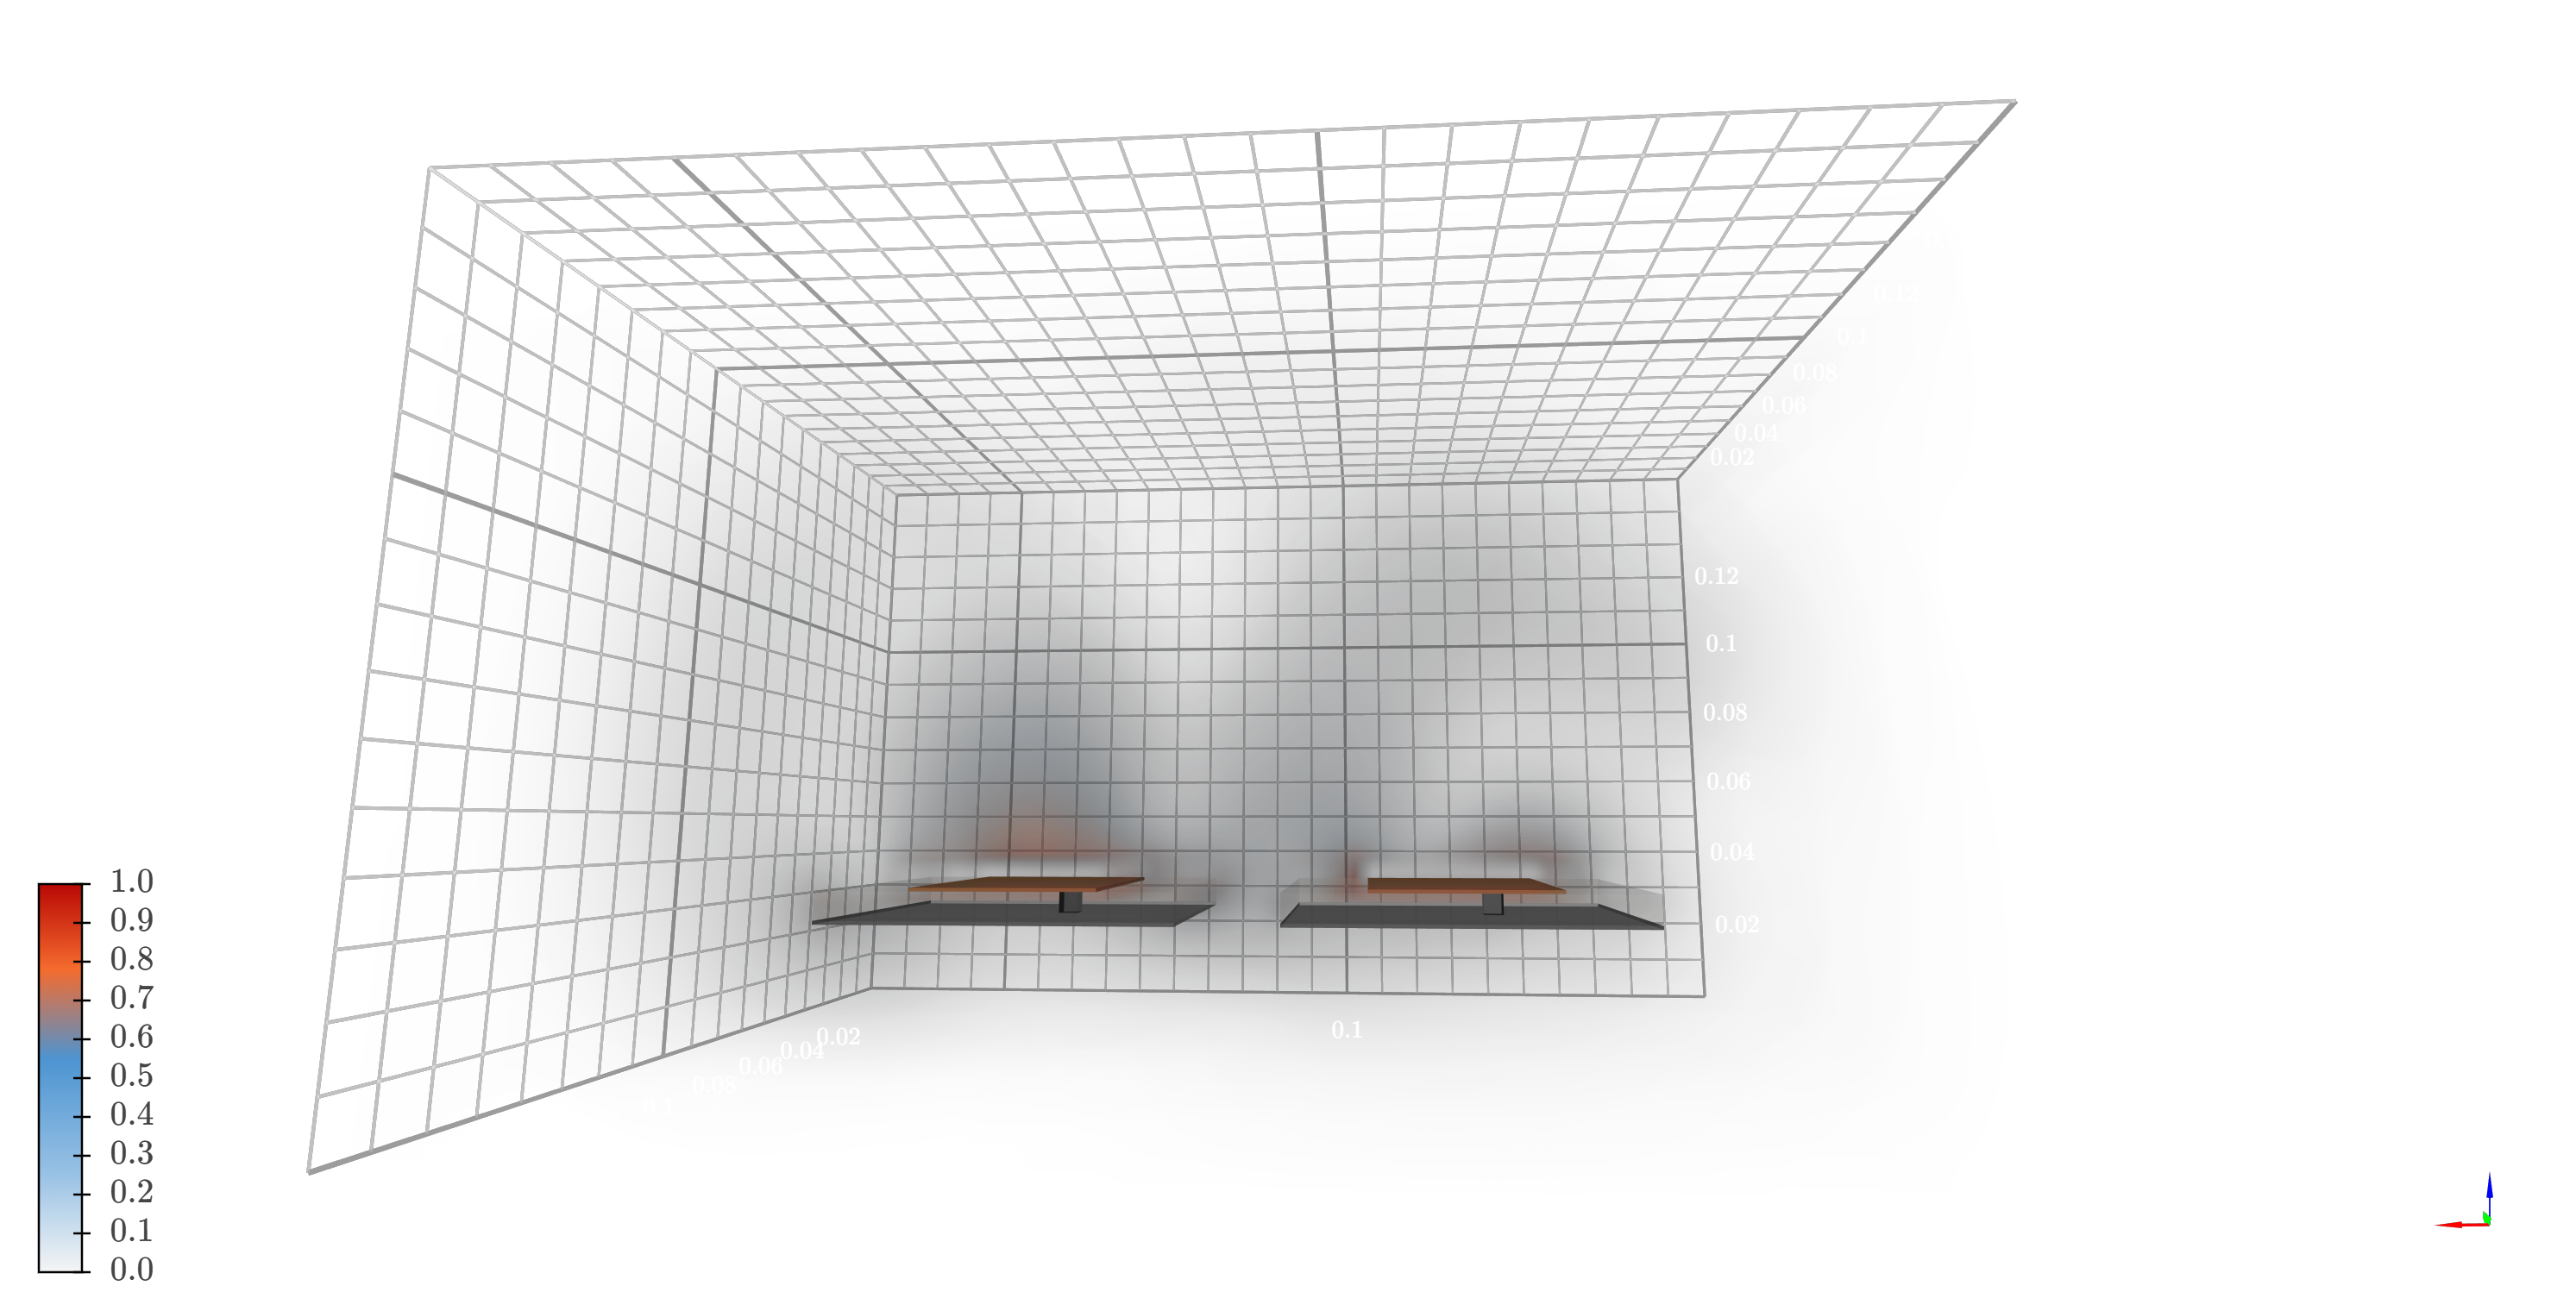